In [ ]:
!pip install pandas openpyxl
import pandas as pd



In [ ]:
from google.colab import files

# Dosyayı yükle
uploaded = files.upload()


# Yeni Bölüm

In [ ]:
df = pd.read_excel("Data annotation.xlsx")
df.head()

,Age,Gender,Location,Sound type,Diagnosis,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,"Posterior: P Lower: L Left: L Right R, UPPER: U, ANTERIOR: A, MIDDLE: M"
0,70.0,M,P L L,I E W,Asthma,NaN,NaN,NaN,NaN,"Insipratory: I, Experiatory: E, Wheezes: W, Cr..."
1,52.0,F,P L L,E W,Asthma,NaN,NaN,NaN,NaN,Crep:crepitations
2,50.0,F,P L L,I E W,Asthma,NaN,NaN,NaN,NaN,NaN
3,72.0,F,P R L,I C,Heart Failure + Lung Fibrosis,NaN,NaN,NaN,NaN,NaN
4,71.0,M,P R L,I C E W,Heart Failure + COPD,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.columns

Index(['Age', 'Gender', 'Location', 'Sound type', 'Diagnosis', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8',
       'Posterior: P Lower: L Left: L Right R, UPPER: U, ANTERIOR: A, MIDDLE: M'],
      dtype='object')

In [ ]:
df.drop(columns=['Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8',
       'Posterior: P Lower: L Left: L Right R, UPPER: U, ANTERIOR: A, MIDDLE: M'], inplace=True)


In [ ]:
df.head()

,Age,Gender,Location,Sound type,Diagnosis
0,70.0,M,P L L,I E W,Asthma
1,52.0,F,P L L,E W,Asthma
2,50.0,F,P L L,I E W,Asthma
3,72.0,F,P R L,I C,Heart Failure + Lung Fibrosis
4,71.0,M,P R L,I C E W,Heart Failure + COPD


In [ ]:
df.nunique()

,0
Age,52
Gender,2
Location,11
Sound type,9
Diagnosis,14


In [ ]:
# 1. Tüm değerleri küçük harfe çevirme ve baştaki/sondaki boşlukları temizleme
df['Diagnosis_cleaned'] = df['Diagnosis'].str.lower().str.strip()

# 2. "+" ile ayrılmış hastalıkları bölme ve her birini ayrı bir giriş olarak işleme
cleaned_diagnoses = df['Diagnosis_cleaned'].dropna().str.split('+').explode().str.strip()

# 3. "and" ile ayrılmış hastalıkları bölme ve her birini ayrı bir giriş olarak işleme
cleaned_diagnoses2 = cleaned_diagnoses.str.split('and').explode().str.strip()

# 4. Benzersiz teşhislerin sayısını ve listesini bulma
unique_cleaned_diagnoses_count = cleaned_diagnoses2.nunique()
unique_cleaned_diagnoses = cleaned_diagnoses2.unique()

# Sonuçları yazdırma
print(f"Benzersiz hastalık sayısı: {unique_cleaned_diagnoses_count}")
print(f"Hastalıklar: {unique_cleaned_diagnoses}")


Benzersiz hastalık sayısı: 8
Hastalıklar: ['asthma' 'heart failure' 'lung fibrosis' 'copd' 'plueral effusion'
 'pneumonia' 'bron' 'n']


In [ ]:
# Hastalıkların İngilizce isimleri ve Türkçe karşılıklarını içeren bir sözlük
disease_translation = {
    'asthma': 'Astım',
    'heart failure': 'Kalp Yetmezliği',
    'lung fibrosis': 'Akciğer Fibrozu',
    'copd': 'KOAH',
    'plueral effusion': 'Plevral Effüzyon',
    'pneumonia': 'Akciğer İltihaplanması',
    'bron': 'BRON',
    'n': 'Normal'
}

# İngilizce hastalıkları Türkçeye çevirmek
translated_diseases = [disease_translation.get(d, d) for d in unique_cleaned_diagnoses]

# Sonuçları yazdırma
print(f"Benzersiz hastalık sayısı: {unique_cleaned_diagnoses_count}")
print(f"Hastalıklar (Türkçe): {translated_diseases}")


Benzersiz hastalık sayısı: 8
Hastalıklar (Türkçe): ['Astım', 'Kalp Yetmezliği', 'Akciğer Fibrozu', 'KOAH', 'Plevral Effüzyon', 'Akciğer İltihaplanması', 'BRON', 'Normal']


# Ses Dosyası Yükleme


In [ ]:
!pip install playsound  # playsound'un kurulumu

  Preparing metadata (setup.py) ... done
  Created wheel for playsound: filename=playsound-1.3.0-py3-none-any.whl size=7020 sha256=3e1c6e77e218ad4c70640673ae4d864667a7aba7e7b74c9a4293cf5118e95831
  Stored in directory: /root/.cache/pip/wheels/50/98/42/62753a9e1fb97579a0ce2f84f7db4c21c09d03bb2091e6cef4
Successfully built playsound


In [ ]:
from IPython.display import Audio
from google.colab import drive
import torch
import librosa.display
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import torchaudio
import librosa
import os
import re

In [ ]:
# Google Drive'ı bağlama
drive.mount('/content/drive')

# Google Drive'daki klasör yolu
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files"

Mounted at /content/drive


In [ ]:
# Google Drive'ı bağlama
drive.mount('/content/drive')

# Google Drive'daki klasör yolu
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files"

# Dizindeki dosyaları listeleme
try:
    file_names = os.listdir(directory)
    for file_name in file_names:
        if file_name.endswith(".wav"):  # Sadece .wav dosyalarını al
            print(file_name)
            file_path = os.path.join(directory, file_name)
            print(f"Dosya yolu: {file_path}")
except FileNotFoundError:
    print(f"Hata: '{directory}' dizini bulunamadı. Lütfen doğru bir yol girin.")

Mounted at /content/drive
BP109_N,N,P L M,26,M.wav
Dosya yolu: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files/BP109_N,N,P L M,26,M.wav
BP107_Asthma,E W,P L U,59,F.wav
Dosya yolu: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files/BP107_Asthma,E W,P L U,59,F.wav
BP108_COPD,E W,P R L ,63,M.wav
Dosya yolu: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files/BP108_COPD,E W,P R L ,63,M.wav
BP102_N,N,P L L,41,M.wav
Dosya yolu: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files/BP102_N,N,P L L,41,M.wav
BP101_Asthma,E W,P L M,12,F.wav
Dosya yolu: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files/BP101_Asthma,E W,P L M,12,F.wav
BP103_N,N,P R U,81,F.wav
Dosya yolu: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files/BP103_N,N,P R U,81,F.wav
BP106_Asthma,E W,P L U,45,F.wav
Dosya yolu: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files/BP106_A

In [ ]:
# Etiketleri saklayacak liste
labels = []

# Dizin içindeki dosyaları gez
for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):  # Sadece wav dosyalarını al
        file_name = file_name.strip()  # Olası boşlukları temizle
        match = re.match(
                r'^([BED]P\d+)_([^,]+),([^,]+),([^,]+),(\d+),?(M|F)\.wav$', file_name
            )

        if match:
            patient_id = match.group(1)
            diagnosis = match.group(2).strip()
            sound_type = match.group(3).strip()
            measurement_location = match.group(4).strip()
            age = int(match.group(5))
            gender = match.group(6)

            # Etiketler listesine ekle
            labels.append({
                "file_name": file_name,
                "patient_id": patient_id,
                "diagnosis": diagnosis,
                "sound_type": sound_type,
                "measurement_location": measurement_location,
                "age": age,
                "gender": gender
            })
        else:
            print(f"No match for file: {file_name}")  # Regex'e uymayan dosyaları yazdır
# Etiketlerin çıktısını gözlemle
for label in labels:
    print(label)

{'file_name': 'BP109_N,N,P L M,26,M.wav', 'patient_id': 'BP109', 'diagnosis': 'N', 'sound_type': 'N', 'measurement_location': 'P L M', 'age': 26, 'gender': 'M'}
{'file_name': 'BP107_Asthma,E W,P L U,59,F.wav', 'patient_id': 'BP107', 'diagnosis': 'Asthma', 'sound_type': 'E W', 'measurement_location': 'P L U', 'age': 59, 'gender': 'F'}
{'file_name': 'BP108_COPD,E W,P R L ,63,M.wav', 'patient_id': 'BP108', 'diagnosis': 'COPD', 'sound_type': 'E W', 'measurement_location': 'P R L', 'age': 63, 'gender': 'M'}
{'file_name': 'BP102_N,N,P L L,41,M.wav', 'patient_id': 'BP102', 'diagnosis': 'N', 'sound_type': 'N', 'measurement_location': 'P L L', 'age': 41, 'gender': 'M'}
{'file_name': 'BP101_Asthma,E W,P L M,12,F.wav', 'patient_id': 'BP101', 'diagnosis': 'Asthma', 'sound_type': 'E W', 'measurement_location': 'P L M', 'age': 12, 'gender': 'F'}
{'file_name': 'BP103_N,N,P R U,81,F.wav', 'patient_id': 'BP103', 'diagnosis': 'N', 'sound_type': 'N', 'measurement_location': 'P R U', 'age': 81, 'gender': 

In [ ]:
len(labels)

324

In [ ]:
# Diagnosis etiketlerini alma ve ön işleme
try:
    diagnoses = [entry['diagnosis'] for entry in labels]  # Tüm diagnosis etiketlerini al

    # Örnek: Benzersiz etiketleri listeleme
    unique_labels = set(diagnoses)
    print(f"Benzersiz etiketler: {unique_labels}")

    # Eğer belirli bir ön işleme yapacaksanız, buraya ekleyin
    # Örneğin: Etiketlerin sayısını hesaplama
    label_counts = {label: diagnoses.count(label) for label in unique_labels}
    print("Etiketlerin dağılımı:")
    for label, count in label_counts.items():
        print(f"{label}:{count}")

except KeyError as e:
    print(f"Hata: Bir kayıt 'diagnosis' anahtarını içermiyor: {e}")
except Exception as e:
    print(f"Beklenmeyen bir hata oluştu: {e}")

Benzersiz etiketler: {'N', 'Lung Fibrosis', 'asthma', 'COPD', 'Heart Failure', 'pneumonia', 'BRON', 'Plueral Effusion', 'heart failure', 'Asthma', 'copd'}
Etiketlerin dağılımı:
N:105
Lung Fibrosis:12
asthma:45
COPD:24
Heart Failure:9
pneumonia:15
BRON:9
Plueral Effusion:6
heart failure:45
Asthma:51
copd:3


In [ ]:
label = [x.lower() for x in diagnoses]


print(len(label))
set(label)

324


{'asthma',
 'bron',
 'copd',
 'heart failure',
 'lung fibrosis',
 'n',
 'plueral effusion',
 'pneumonia'}

In [ ]:
label = [x.lower().strip() for x in diagnoses]  # Küçük harf ve boşluk temizliği

for i in range(len(label)):
    if 'asthma' in label[i]:
        label[i] = 'asthma'
    elif 'bron' in label[i]:
        label[i] = 'bron'
    elif 'copd' in label[i]:
        label[i] = 'copd'
    elif 'heart failure' in label[i]:
        label[i] = 'heart failure'
    elif 'lung fibrosis' in label[i]:
        label[i] = 'lung fibrosis'
    elif 'pleural effusion' in label[i] or 'plueral effusion' in label[i]:
        label[i] = 'pleural effusion'
    elif 'pneumonia' in label[i]:
        label[i] = 'pneumonia'
    elif label[i] == 'n':
        continue
    else:
        print(f"Bilinmeyen sınıf: {label[i]}")
set(label)

{'asthma',
 'bron',
 'copd',
 'heart failure',
 'lung fibrosis',
 'n',
 'pleural effusion',
 'pneumonia'}

In [ ]:
# One-hot encode labels
le = LabelEncoder()
i_labels = le.fit_transform(label)
oh_labels = to_categorical(i_labels)
print(oh_labels)
print(len(oh_labels))
print("Sınıf isimleri:", le.classes_)
print("One-hot vektör şekli:", oh_labels.shape)

[[0. 0. 0. ... 1. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]]
324
Sınıf isimleri: ['asthma' 'bron' 'copd' 'heart failure' 'lung fibrosis' 'n'
 'pleural effusion' 'pneumonia']
One-hot vektör şekli: (324, 8)


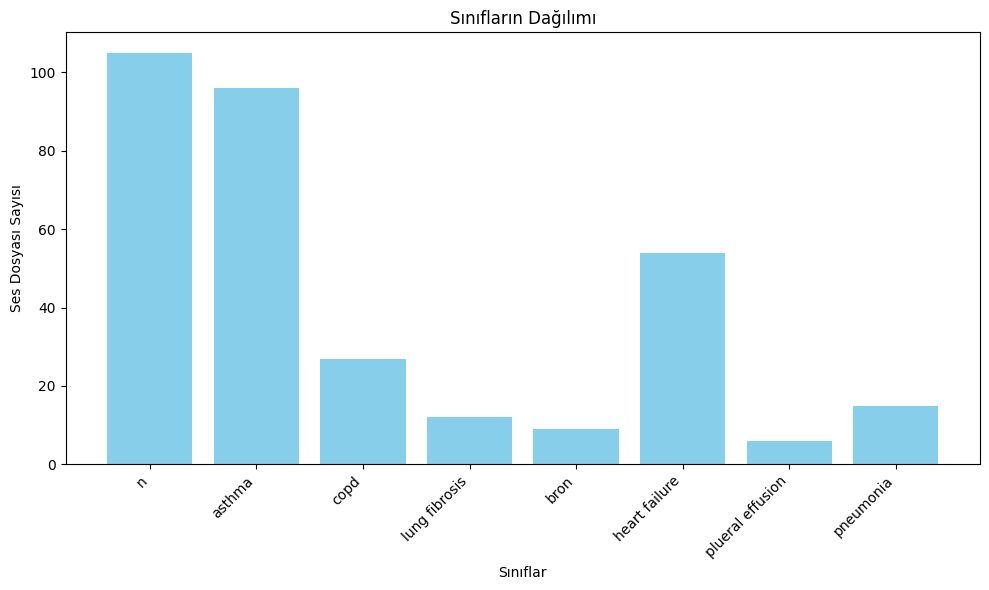

In [ ]:
# Sınıf etiketleri ve dosya sayılarını saklamak için sözlük
class_counts = {}

# Ses dosyalarını ve etiketlerini yükle
for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):
        # Dosya adından etiketi çıkar (örnek: 'EP69_pneumonia,Bronchial,P R L ,64,M.wav' -> 'pneumonia')
        label = file_name.split('_')[1].split(',')[0].strip().lower()

        # Etiketi sözlüğe ekle veya sayacı artır
        if label in class_counts:
            class_counts[label] += 1
        else:
            class_counts[label] = 1

# Grafik oluşturma
labels = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
plt.title('Sınıfların Dağılımı')
plt.xlabel('Sınıflar')
plt.ylabel('Ses Dosyası Sayısı')
plt.xticks(rotation=45, ha='right')  # Etiketlerin okunabilirliği için döndürme
plt.tight_layout()  # Grafik öğelerinin üst üste binmesini önleme
plt.show()

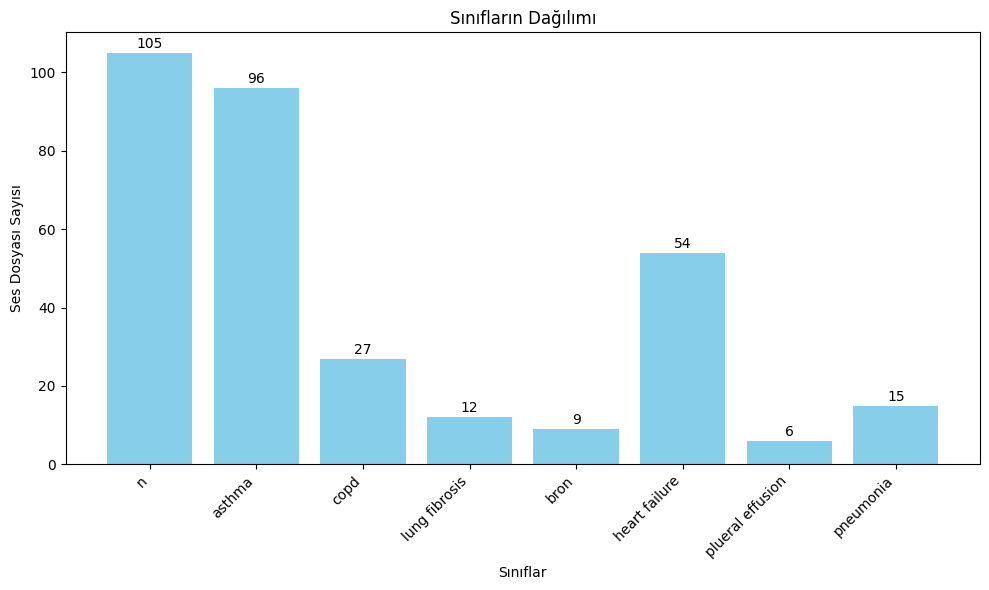

In [ ]:
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files"

# Sınıf etiketleri ve dosya sayılarını saklamak için sözlük
u_class_counts = {}

# Etiketleme işlemi
label = [x.lower().strip() for x in diagnoses]  # Küçük harf ve boşluk temizliği

# Etiketlerin düzenlenmesi
for i in range(len(label)):
    # Kombinasyon hastalık adları
    if 'asthma and lung fibrosis' in label[i]:
        label[i] = 'asthma'
    elif 'heart failure + copd' in label[i] or 'heart failure + lung fibrosis' in label[i]:
        label[i] = 'heart failure'

    elif 'asthma' in label[i]:
        label[i] = 'asthma'
    elif 'bron' in label[i]:
        label[i] = 'bron'
    elif 'copd' in label[i]:
        label[i] = 'copd'
    elif 'heart failure' in label[i]:
        label[i] = 'heart failure'
    elif 'lung fibrosis' in label[i]:
        label[i] = 'lung fibrosis'
    elif 'pleural effusion' in label[i] or 'plueral effusion' in label[i]:
        label[i] = 'plueral effusion'
    elif 'pneumonia' in label[i]:
        label[i] = 'pneumonia'
    elif label[i] == 'n':
        continue
    else:
        print(f"Bilinmeyen sınıf: {label[i]}")
        continue

# Ses dosyalarını ve etiketlerini yükle
for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):
        # Dosya adından etiketi çıkar (örnek: 'EP69_pneumonia,Bronchial,P R L ,64,M.wav' -> 'pneumonia')
        file_label = file_name.split('_')[1].split(',')[0].strip().lower()

        # Etiketi düzenle
        if file_label in label:
            label_name = label[label.index(file_label)]

            # Etiketi sözlüğe ekle veya sayacı artır
            if label_name in u_class_counts:
                u_class_counts[label_name] += 1
            else:
                u_class_counts[label_name] = 1

# Grafik oluşturma
labels = list(u_class_counts.keys())
counts = list(u_class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
for i, count in enumerate(counts):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)
plt.title('Sınıfların Dağılımı')
plt.xlabel('Sınıflar')
plt.ylabel('Ses Dosyası Sayısı')
plt.xticks(rotation=45, ha='right')  # Etiketlerin okunabilirliği için döndürme
plt.tight_layout()  # Grafik öğelerinin üst üste binmesini önleme
plt.show()


ses dosyalarının öznitelik çıkarımı

In [ ]:
# Klasördeki tüm ses dosyalarını al
audio_files = [f for f in os.listdir(directory) if f.endswith('.wav')]

# Her bir ses dosyasını işleyip MFCC çıkartma
for file in audio_files:
    file_path = os.path.join(directory, file)
    print(f"Processing file: {file_path}")

    # Ses dosyasını yükleme
    y, sr = librosa.load(file_path, sr=None)

    # MFCC özniteliklerini çıkarma
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

    # MFCC'yi görselleştirme
    plt.figure(figsize=(10, 6))
    librosa.display.specshow(mfcc, x_axis='time', sr=sr)
    plt.colorbar()
    plt.title(f'MFCC for {file}')
    plt.show()

    # MFCC'nin şekli
    print(f"MFCC shape for {file}: {mfcc.shape}")



In [ ]:
# Klasördeki tüm ses dosyalarını al
audio_files = [f for f in os.listdir(directory) if f.endswith('.wav')]

# MFCC özniteliklerini çıkarma fonksiyonu
def extract_mfcc(file_path):
    waveform, sample_rate = torchaudio.load(file_path)

    # MFCC özniteliklerini çıkarma (40 MFCC katsayısı)
    mfcc_transform = torchaudio.transforms.MFCC(
        sample_rate=sample_rate,
        n_mfcc=40,  # Çıkartılacak MFCC sayısı
        melkwargs={"n_fft": 400, "hop_length": 160, "n_mels": 40}
    )

    # MFCC özniteliklerini çıkar
    mfcc = mfcc_transform(waveform)
    return mfcc

# MFCC'leri saklayacağımız liste
mfcc_features_list = []

# Tüm ses dosyaları için MFCC çıkarımı
for audio_file in audio_files:
    file_path = os.path.join(directory, audio_file)
    mfcc = extract_mfcc(file_path)
    mfcc_features_list.append(mfcc)
    print(f"File: {audio_file} - MFCC shape: {mfcc.shape}")

File: BP109_N,N,P L M,26,M.wav - MFCC shape: torch.Size([1, 40, 331])
File: BP107_Asthma,E W,P L U,59,F.wav - MFCC shape: torch.Size([1, 40, 317])
File: BP108_COPD,E W,P R L ,63,M.wav - MFCC shape: torch.Size([1, 40, 571])
File: BP102_N,N,P L L,41,M.wav - MFCC shape: torch.Size([1, 40, 477])
File: BP101_Asthma,E W,P L M,12,F.wav - MFCC shape: torch.Size([1, 40, 339])
File: BP103_N,N,P R U,81,F.wav - MFCC shape: torch.Size([1, 40, 322])
File: BP106_Asthma,E W,P L U,45,F.wav - MFCC shape: torch.Size([1, 40, 496])
File: BP104_Asthma,E W,P L U,45,F.wav - MFCC shape: torch.Size([1, 40, 295])
File: BP100_N,N,P R M,70,F.wav - MFCC shape: torch.Size([1, 40, 339])
File: BP105_Lung Fibrosis,Crep,A U R,44,M.wav - MFCC shape: torch.Size([1, 40, 632])
File: DP23_Lung Fibrosis,Crep,P R L ,50,M.wav - MFCC shape: torch.Size([1, 40, 285])
File: BP28_BRON,Crep,P L U,68,F.wav - MFCC shape: torch.Size([1, 40, 397])
File: BP93_N,N,P R M,75,M.wav - MFCC shape: torch.Size([1, 40, 247])
File: BP27_asthma,E W,

In [ ]:
for i, mfcc in enumerate(mfcc_features_list[:5]):  # İlk 5 dosya için
    print(f"File {i+1}: MFCC Shape = {mfcc.shape}")

# En uzun sütun boyutunu bulma
max_length = max([x.shape[2] for x in mfcc_features_list])

print(f"En uzun sütun boyutu: {max_length}")


File 1: MFCC Shape = torch.Size([1, 40, 331])
File 2: MFCC Shape = torch.Size([1, 40, 317])
File 3: MFCC Shape = torch.Size([1, 40, 571])
File 4: MFCC Shape = torch.Size([1, 40, 477])
File 5: MFCC Shape = torch.Size([1, 40, 339])
En uzun sütun boyutu: 751


In [ ]:
# Ses dosyasını çal
audio_file = '/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files/EP69_pneumonia,Bronchial,P R L ,64,M.wav'
Audio(audio_file)  # Sesi çalmak için IPython.display.Audio kullanın


MFCC boyutunu incelemek gerekirse  
torch.Size([1, 40, 317])

1: Bu, tek bir ses dosyası için MFCC özelliklerinin çıkarıldığını gösterir. Başka bir deyişle, bu tek bir ses kaydını temsil eder. Eğer birden fazla ses dosyası işliyor olsaydınız, bu boyut, işlenen ses dosyalarının sayısına eşit olurdu.

40: Bu, her bir zaman çerçevesi için çıkarılan MFCC katsayılarının sayısını gösterir. n_mfcc parametresi ile bu sayıyı belirlemiştik (n_mfcc=40 olarak ayarlanmıştır). MFCC'ler, sesin spektral zarfının temsilini sağlayan özelliklerdir ve genellikle 13 katsayı kullanılır. 23,40 vs gibi sayılarda kullanılır.

317: Bu, ses dosyasının zaman boyutunu temsil eder ve sesin kaç zaman çerçevesine bölündüğünü gösterir. Bu sayı, ses dosyasının uzunluğuna, örnekleme hızına ve MFCC hesaplamasında kullanılan pencere boyutuna ve adımına bağlı olarak değişir.

In [ ]:
print(f"File: {audio_file} - First 5 MFCC coefficients:")
print(mfcc[:, :5])  # İlk 5 frame'in MFCC öznitelikleri
print("---------------------------------------------------")

File: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files/EP69_pneumonia,Bronchial,P R L ,64,M.wav - First 5 MFCC coefficients:
tensor([[[-174.4782, -193.7527, -203.9116,  ..., -200.2513, -207.4398,
          -199.8410],
         [ 104.3952,   87.4151,   81.4883,  ...,   84.3093,   76.0005,
            84.1676],
         [  57.7292,   58.8109,   66.1898,  ...,   63.7313,   59.5051,
            61.9264],
         [  31.3690,   38.9421,   46.4993,  ...,   39.4523,   38.6586,
            36.2027],
         [  28.8362,   31.3131,   28.3396,  ...,   19.6748,   20.1856,
            16.1095]]])
---------------------------------------------------


In [ ]:
# En uzun zaman penceresinin uzunluğunu bulma
max_length = max([x.shape[2] for x in mfcc_features_list])

# Padding işlemi
def pad_mfcc(mfcc, max_length):
    # MFCC matrisini, en uzun zaman penceresinin uzunluğuna kadar sıfırlarla doldur
    padded_mfcc = torch.nn.functional.pad(mfcc, (0, max_length - mfcc.shape[2]))
    return padded_mfcc

# Tüm MFCC'leri padding ile hizalama
padded_mfcc_features_list = []
for mfcc in mfcc_features_list:
    padded_mfcc = pad_mfcc(mfcc, max_length)
    padded_mfcc_features_list.append(padded_mfcc)

# Padding uygulanmış MFCC'lerin boyutlarını yazdırma
for i, padded_mfcc in enumerate(padded_mfcc_features_list[:5]):  # İlk 5 dosya için
    print(f"File {i+1}: Padded MFCC Shape = {padded_mfcc.shape}")

File 1: Padded MFCC Shape = torch.Size([1, 40, 751])
File 2: Padded MFCC Shape = torch.Size([1, 40, 751])
File 3: Padded MFCC Shape = torch.Size([1, 40, 751])
File 4: Padded MFCC Shape = torch.Size([1, 40, 751])
File 5: Padded MFCC Shape = torch.Size([1, 40, 751])


In [ ]:
# Tüm MFCC'leri görselleştirme
for i, mfcc in enumerate(mfcc_features_list):
    plt.figure(figsize=(10, 4))
    # MFCC verisinin 2. boyutunu (40 MFCC katsayısı) görüntülemek için [0] indeksini kullanın
    plt.imshow(mfcc[0], aspect='auto', origin='lower', cmap='viridis')
    plt.colorbar()
    plt.title(f"MFCC - File {i+1}")
    plt.xlabel("Zaman")
    plt.ylabel("MFCC Katsayıları")
    plt.tight_layout()
    plt.show()


In [ ]:
train_tensor = torch.stack(train_mfcc_padded)
val_tensor = torch.stack(val_mfcc_padded)
test_tensor = torch.stack(test_mfcc_padded)

print(f"Train tensor shape: {train_tensor.shape}")
print(f"Validation tensor shape: {val_tensor.shape}")
print(f"Test tensor shape: {test_tensor.shape}")


Train tensor shape: torch.Size([197, 1, 40, 751])
Validation tensor shape: torch.Size([42, 1, 40, 751])
Test tensor shape: torch.Size([43, 1, 40, 751])


Görsel, bir ses dosyasının Mel Frekans Cepstral Katsayıları (MFCC) özelliğini gösteriyor. MFCC'ler, bir ses dosyasının spektral zarfının temsilini sağlayan özelliklerdir. Başka bir deyişle, bir ses dosyasının zaman içindeki frekans içeriği bilgisini özetlerler.

Görseli analiz edersek:

X ekseni: Zamanı temsil eder. Ses dosyası zaman içinde çerçevelere bölünür ve her bir çerçeve için MFCC özellikleri çıkarılır. X ekseni, bu çerçevelerin zaman içindeki ilerlemesini gösterir.

Y ekseni: MFCC katsayılarını temsil eder. Genellikle 40 MFCC katsayısı çıkarılır ve bunlar, sesin farklı frekans bantlarında enerjisinin yoğunluğunu gösterir. Y ekseni, bu katsayıların indeksini gösterir.

Renk: Her bir pikselin rengi, o zaman ve frekans noktasındaki MFCC değerini gösterir. Renk skalası genellikle mavi (düşük değerler) ile kırmızı (yüksek değerler) arasında değişir. Koyu renkler, o frekans bandında daha az enerji olduğunu, parlak renkler ise daha fazla enerji olduğunu gösterir.

Özetle: Görsel, ses dosyasının zaman içindeki frekans içeriği bilgisini temsil eder. Zamana bağlı olarak farklı frekans bantlarındaki enerji yoğunluğunu göstererek, sesin karakteristik özelliklerini görselleştirmemizi sağlar.

In [ ]:
# Normalizasyon işlemi
def normalize_mfcc(mfcc):
    # MFCC'yi normalleştir
    mean = mfcc.mean(dim=-1, keepdim=True)  # MFCC'nin her bir zaman penceresi için ortalama
    std = mfcc.std(dim=-1, keepdim=True)    # MFCC'nin her bir zaman penceresi için standart sapma
    normalized_mfcc = (mfcc - mean) / std
    return normalized_mfcc

# Normalizasyon uygulama
normalized_mfcc_features_list = []
for mfcc in padded_mfcc_features_list:
    normalized_mfcc = normalize_mfcc(mfcc)
    normalized_mfcc_features_list.append(normalized_mfcc)



In [ ]:
# Düzleştirme (Flattening) işlemi
def flatten_mfcc(mfcc):
    # (1, 40, N) boyutundaki MFCC'yi (40 * N) şeklinde düzleştir
    return mfcc.reshape(-1)

# Düzleştirme işlemi
flattened_mfcc_features_list = []
for mfcc in normalized_mfcc_features_list:
    flattened_mfcc = flatten_mfcc(mfcc)
    flattened_mfcc_features_list.append(flattened_mfcc)



In [ ]:
# Padding, normalizasyon ve düzleştirilmiş MFCC matrislerinin boyutlarını yazdırma
for i, flattened_mfcc in enumerate(flattened_mfcc_features_list[:5]):  # İlk 5 dosya için
    print(f"File {i+1}: Flattened MFCC Shape = {flattened_mfcc.shape}")

File 1: Flattened MFCC Shape = torch.Size([30040])
File 2: Flattened MFCC Shape = torch.Size([30040])
File 3: Flattened MFCC Shape = torch.Size([30040])
File 4: Flattened MFCC Shape = torch.Size([30040])
File 5: Flattened MFCC Shape = torch.Size([30040])


# Model Eğitimi

In [ ]:
X = np.array([x.numpy() for x in normalized_mfcc_features_list]) # Padding, normalizasyon ve düzleştirilmiş MFCC matrislerinin listesi
y = np.array(oh_labels)  # Sayısallaştırılmış labellarımız

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

In [ ]:
# One-hot kodlanmış etiketleri sınıf indekslerine dönüştür
y_train_indices = np.argmax(y_train, axis=1)

# Sınıf indekslerini kullanarak sınıf ağırlıklarını hesapla
class_weights = compute_class_weight(class_weight='balanced',
                                    classes=np.unique(y_train_indices),
                                    y=y_train_indices)

# Sınıf ağırlıklarını bir sözlüğe dönüştür
class_weight_dict = dict(enumerate(class_weights))

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
# MLP Modelinin oluşturulması
model = Sequential()

# Girdi katmanı ve ilk gizli katman
model.add(Flatten(input_shape=(40, 751, 1)))  # Girişi düzleştir
model.add(Dense(512, activation='relu', input_shape=(30040,)))  # 30040 giriş nöronu
model.add(Dropout(0.3))  # %30 dropout

# İkinci gizli katman
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))  # %30 dropout

# Çıkış katmanı
model.add(Dense(8, activation='softmax'))  # 8 çıkış nöronu (8 kategori)

# Modelin derlenmesi
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Modelin özetinin yazdırılması
model.summary()

# EarlyStopping callback'ini oluşturma
early_stopping = EarlyStopping(
    monitor='val_loss',  # İzlenecek metrik (doğrulama kaybı)
    patience=10,          # İyileşme olmadan kaç epoch beklenmeli
    restore_best_weights=True  # En iyi ağırlıkları geri yükle
)


# Modelin eğitimi
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping],
                    class_weight=class_weight_dict,
                    verbose=1)

# Modelin değerlendirilmesi
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Kaybı: {loss:.4f}")
print(f"Test Doğruluğu: {accuracy:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 30040)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    15,380,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,514,376 (59.18 MB)

 Trainable params: 15,514,376 (59.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 432ms/step - accuracy: 0.1879 - loss: 5.3539 - val_accuracy: 0.6829 - val_loss: 0.9797
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 490ms/step - accuracy: 0.6343 - loss: 3.8666 - val_accuracy: 0.6098 - val_loss: 1.4352
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 370ms/step - accuracy: 0.6876 - loss: 1.8952 - val_accuracy: 0.8537 - val_loss: 0.9309
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 371ms/step - accuracy: 0.8765 - loss: 0.7588 - val_accuracy: 0.8780 - val_loss: 0.4046
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 552ms/step - accuracy: 0.8283 - loss: 0.5385 - val_accuracy: 0.9024 - val_loss: 0.4867
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 370ms/step - accuracy: 0.9177 - loss: 0.4385 - val_accuracy: 0.8780 - val_loss: 0.6586
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 334ms/step - accuracy: 0.8999 - loss: 0.3086 - val_accuracy: 0.9024 - val_loss: 0.1832
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 412ms/step - accuracy: 0.9124 - loss: 0.4140 - val_accuracy: 0.9024 - v

# MLP Sonuçları

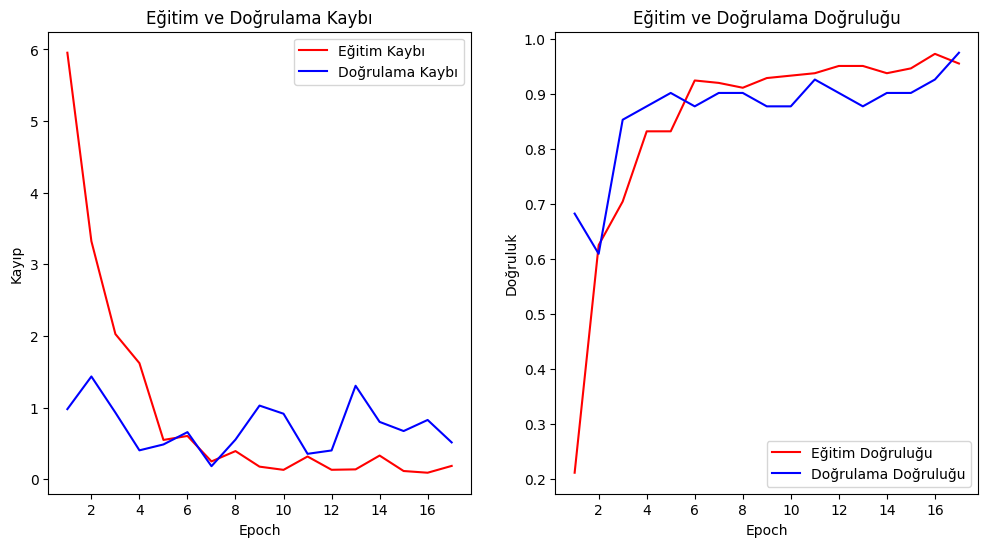

In [ ]:
# Eğitim geçmişinden kayıp ve doğruluk değerlerini al
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Epoch sayısı
epochs = range(1, len(train_loss) + 1)

# Kayıp grafiği
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'r', label='Eğitim Kaybı')
plt.plot(epochs, val_loss, 'b', label='Doğrulama Kaybı')
plt.title('Eğitim ve Doğrulama Kaybı')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.legend()

# Doğruluk grafiği
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, 'r', label='Eğitim Doğruluğu')
plt.plot(epochs, val_acc, 'b', label='Doğrulama Doğruluğu')
plt.title('Eğitim ve Doğrulama Doğruluğu')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()

plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


<Figure size 1000x800 with 0 Axes>

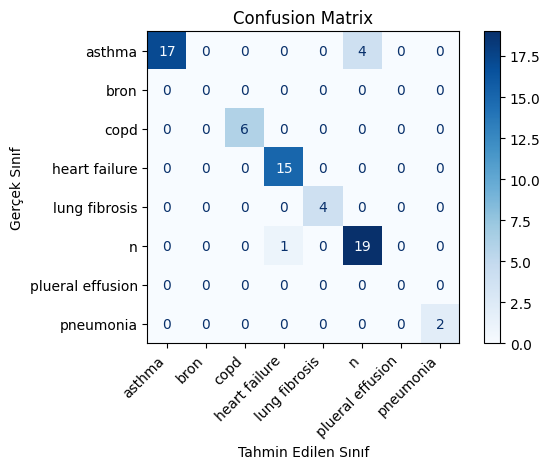

In [ ]:
# Test verisi için tahminleri al
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)  # One-hot'tan orijinal label'a çevir

# Confusion matrix oluştur
all_classes = np.arange(8)
cm = confusion_matrix(y_true, y_pred, labels=all_classes)
class_names = ['asthma','bron','copd','heart failure','lung fibrosis','n','plueral effusion','pneumonia']

# Görselleştir
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(10, 8))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.xticks(rotation=45, ha='right')
plt.grid(False)
plt.tight_layout()
plt.show()


8 sınıf olmasına ragmen 2 tanesi için hiç örnek yok bu yüzden veri arttırma kaçınılmaz oluyor. ya da ağırlıklı kayıp fonksiyonu olabilir. Sınıf dengesizliğini modelin kaybını hesaplarken dikkate alabiliriz. class_weight parametresiyle, azınlık sınıflarına daha fazla önem vererek modelin bu sınıfları öğrenmesini sağlanabilir.


In [ ]:
# y_test: Gerçek etiketler (one-hot değil, sınıf indeksleri)
# y_pred_probs: Modelin tahmin ettiği olasılıklar
# y_pred: En yüksek olasılığı olan sınıf
y_test_indices = np.argmax(y_test, axis=1)


In [ ]:
# Sınıf bazlı precision, recall, f1-score
# Tahminlerde bulunan benzersiz sınıf etiketlerini al
benzersiz_etiketler = np.unique(np.concatenate((y_test_indices, y_pred)))

# Yalnızca mevcut etiketleri içerecek şekilde class_names'i filtrele
mevcut_sinif_adlari = [class_names[i] for i in benzersiz_etiketler]

In [ ]:
# Filtrelenmiş sınıf adlarıyla sınıflandırma raporunu oluştur
report = classification_report(y_test_indices, y_pred, target_names=mevcut_sinif_adlari, zero_division=1)
print(report)

               precision    recall  f1-score   support

       asthma       1.00      0.81      0.89        21
         copd       1.00      1.00      1.00         6
heart failure       0.94      1.00      0.97        15
lung fibrosis       1.00      1.00      1.00         4
            n       0.83      0.95      0.88        20
    pneumonia       1.00      1.00      1.00         2

     accuracy                           0.93        68
    macro avg       0.96      0.96      0.96        68
 weighted avg       0.94      0.93      0.93        68



overfitting durumunu önlemek ve dengesiz veri setini normalleştirebilmek için sınıf ağırlıkları yöntemini kullandım.

Sınıf Ağırlıkları:

Model eğitimi sırasında, az temsil edilen sınıflara daha yüksek ağırlıklar atayarak modelin bu sınıflara daha fazla odaklanmasını sağlayabilmektir.

# 4 sınıflı MLP

In [ ]:
# Klasör yolları
train_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4_clean"
val_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/val4"
test_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/test4"

# Ses dosyalarını alma
train_files = [os.path.join(train_dir, f) for f in os.listdir(train_dir) if f.endswith('.wav')]
val_files = [os.path.join(val_dir, f) for f in os.listdir(val_dir) if f.endswith('.wav')]
test_files = [os.path.join(test_dir, f) for f in os.listdir(test_dir) if f.endswith('.wav')]

print(f"Train: {len(train_files)}, Validation: {len(val_files)}, Test: {len(test_files)}")

Train: 197, Validation: 42, Test: 43


In [ ]:
# 4 sınıflı MLP için MFCC çıkarımı
def extract_mfcc(file_list):
    mfcc_list = []
    for file_path in file_list:
        try:
            waveform, sample_rate = torchaudio.load(file_path)

            mfcc_transform = torchaudio.transforms.MFCC(
                sample_rate=sample_rate,
                n_mfcc=40,
                melkwargs={"n_fft": 400, "hop_length": 160, "n_mels": 40}
            )

            mfcc = mfcc_transform(waveform)
            mfcc_list.append(mfcc)

            print(f"File: {file_path} - MFCC shape: {mfcc.shape}")

        except Exception as e:
            print(f"Hata oluştu: {file_path} - {e}")

    return mfcc_list


In [ ]:
train_mfcc = extract_mfcc(train_files)
val_mfcc = extract_mfcc(val_files)
test_mfcc = extract_mfcc(test_files)

File: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4_clean/DP14_Heart Failure,C,A R M,54,M.wav - MFCC shape: torch.Size([1, 40, 320])
File: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4_clean/EP35_Asthma,E W,A R L,38,M.wav - MFCC shape: torch.Size([1, 40, 400])
File: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4_clean/DP101_Asthma,E W,P L M,12,F.wav - MFCC shape: torch.Size([1, 40, 339])
File: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4_clean/BP25_copd,E W,P L L,76,M.wav - MFCC shape: torch.Size([1, 40, 287])
File: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4_clean/DP32_N,N,A R L,30,M.wav - MFCC shape: torch.Size([1, 40, 459])
File: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4_clean/DP81_N,N,P L U,33,M.wav - MFCC shape: torch.Size([1, 40, 589])
File: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4_clean/EP62_COPD,E W,P L M,53,M.wav -

In [ ]:
# En uzun zaman penceresini bul
max_length = max(
    max(mfcc.shape[2] for mfcc in train_mfcc),
    max(mfcc.shape[2] for mfcc in val_mfcc),
    max(mfcc.shape[2] for mfcc in test_mfcc)
)

# Padding fonksiyonu
def pad_mfcc(mfcc_list, max_length):
    padded_list = []
    for mfcc in mfcc_list:
        padding_size = max_length - mfcc.shape[2]
        padded_mfcc = torch.nn.functional.pad(mfcc, (0, padding_size))
        padded_list.append(padded_mfcc)
    return padded_list

# Padding işlemi
train_mfcc_padded = pad_mfcc(train_mfcc, max_length)
val_mfcc_padded = pad_mfcc(val_mfcc, max_length)
test_mfcc_padded = pad_mfcc(test_mfcc, max_length)


In [ ]:
import numpy as np

# Normalizasyon fonksiyonu (z-score normalization)
def normalize_mfcc(mfcc_array, epsilon=1e-8):
    mean = np.mean(mfcc_array, axis=(1, 2), keepdims=True)
    std = np.std(mfcc_array, axis=(1, 2), keepdims=True)
    std = np.where(std == 0, epsilon, std)  # std=0 olanlara küçük değer ata
    normalized = (mfcc_array - mean) / std
    return normalized

# Flatten fonksiyonu
def flatten_mfcc(mfcc_array):
    num_samples = mfcc_array.shape[0]
    return mfcc_array.reshape(num_samples, -1)

# Tüm işlem (normalize + flatten)
def preprocess_mfcc_dataset(mfcc_tensor):
    mfcc_array = mfcc_tensor.numpy()  # PyTorch tensor -> NumPy array
    normalized = normalize_mfcc(mfcc_array)
    flattened = flatten_mfcc(normalized)
    return flattened

# Train
X_train = preprocess_mfcc_dataset(train_tensor)
print(f"Train final shape: {X_train.shape}")

# Validation
X_val = preprocess_mfcc_dataset(val_tensor)
print(f"Validation final shape: {X_val.shape}")

# Test
X_test = preprocess_mfcc_dataset(test_tensor)
print(f"Test final shape: {X_test.shape}")



Train final shape: (197, 30040)
Validation final shape: (42, 30040)
Test final shape: (43, 30040)


In [ ]:
def extract_labels(file_paths):
    labels = []
    for file_path in file_paths:
        file_name = os.path.basename(file_path).lower()

        if '_n,n,' in file_name:
            labels.append('n')
        elif 'asthma' in file_name:
            labels.append('asthma')
        elif 'copd' in file_name:
            labels.append('copd')
        elif 'heart failure' in file_name:
            labels.append('heart failure')
        else:
            print(f"Bilinmeyen etiket: {file_name}")
            labels.append('unknown')

    return labels


In [ ]:
train_labels = extract_labels(train_files)
val_labels = extract_labels(val_files)
test_labels = extract_labels(test_files)

print(f"Train Labels: {len(train_labels)}")
print(f"Validation Labels: {len(val_labels)}")
print(f"Test Labels: {len(test_labels)}")


Train Labels: 197
Validation Labels: 42
Test Labels: 43


In [ ]:
import numpy as np

# Önce tüm unique label setini çıkaralım
unique_labels = sorted(list(set(train_labels + val_labels + test_labels)))
label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
num_classes = len(unique_labels)

# Tek fonksiyonla integer + one-hot encoding
def encode_labels(labels):
    integer_encoded = np.array([label_to_index[label] for label in labels])
    one_hot_encoded = np.eye(num_classes)[integer_encoded]
    return one_hot_encoded

# Her set için ayrı ayrı encode işlemi
y_train = encode_labels(train_labels)
y_val = encode_labels(val_labels)
y_test = encode_labels(test_labels)

print(f"Train labels one-hot shape: {y_train.shape}")
print(f"Validation labels one-hot shape: {y_val.shape}")
print(f"Test labels one-hot shape: {y_test.shape}")


Train labels one-hot shape: (197, 4)
Validation labels one-hot shape: (42, 4)
Test labels one-hot shape: (43, 4)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Model oluşturma
model = Sequential([
    Input(shape=(input_size,)),  # İlk katmanda input veriyoruz
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')  # 4 sınıf
])

# Modeli derle
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model özeti
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 512)            │    15,380,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,513,348 (59.18 MB)

 Trainable params: 15,513,348 (59.18 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Modeli eğit
history = model.fit(
    X_train,  # Shape: (num_samples, input_size)
    y_train,  # One-hot encoded labels, Shape: (num_samples, 4)
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

# Test seti üzerinde değerlendirme
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Kaybı: {loss:.4f}")
print(f"Test Doğruluğu: {accuracy:.4f}")

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 285ms/step - accuracy: 0.2505 - loss: 5.5702 - val_accuracy: 0.4048 - val_loss: 2.1511
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 246ms/step - accuracy: 0.3483 - loss: 3.9375 - val_accuracy: 0.4286 - val_loss: 1.5660
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 241ms/step - accuracy: 0.4086 - loss: 2.9210 - val_accuracy: 0.4286 - val_loss: 1.6470
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 242ms/step - accuracy: 0.3756 - loss: 2.8440 - val_accuracy: 0.5000 - val_loss: 1.2481
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 331ms/step - accuracy: 0.4146 - loss: 1.9332 - val_accuracy: 0.4048 - val_loss: 1.2499
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 359ms/step - accuracy: 0.5062 - loss: 1.8402 - val_accuracy: 0.5000 - val_loss: 1.2985
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 240ms/step - accuracy: 0.4427 - loss: 1.5198 - val_accuracy: 0.4762 - val_loss: 1.1881
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 243ms/step - accuracy: 0.5004 - loss: 1.2624 - val_accuracy: 0.5238 - v

In [ ]:
# Model Test Performansı
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Kaybı: {test_loss:.4f}")
print(f"Test Doğruluğu: {test_accuracy:.4f}")


Test Kaybı: 0.3063
Test Doğruluğu: 0.9070


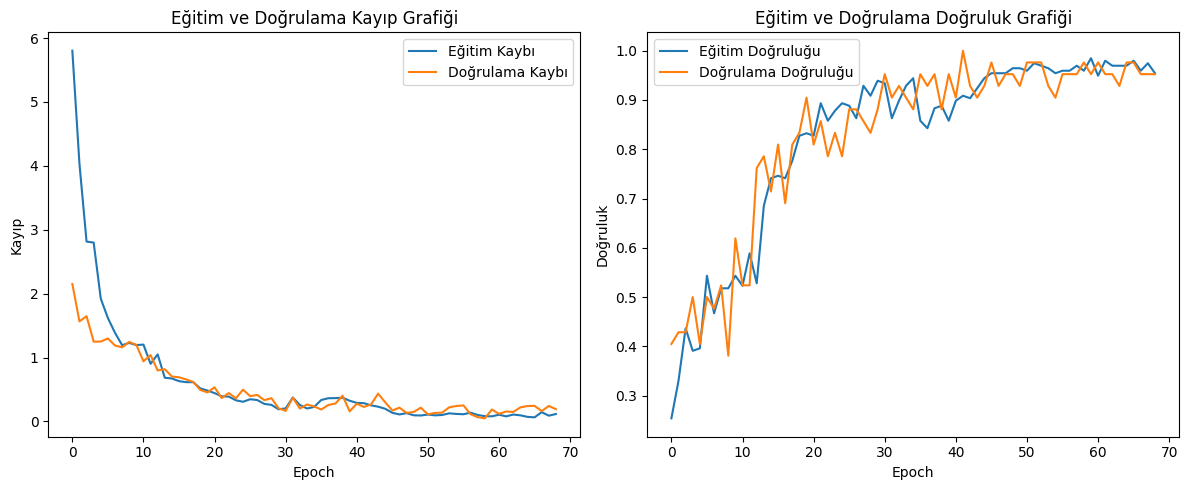

In [ ]:
# Eğitim ve Doğrulama Kayıp Grafiği
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.title('Eğitim ve Doğrulama Kayıp Grafiği')
plt.legend()

# Eğitim ve Doğrulama Doğruluk Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.title('Eğitim ve Doğrulama Doğruluk Grafiği')
plt.legend()

plt.tight_layout()
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


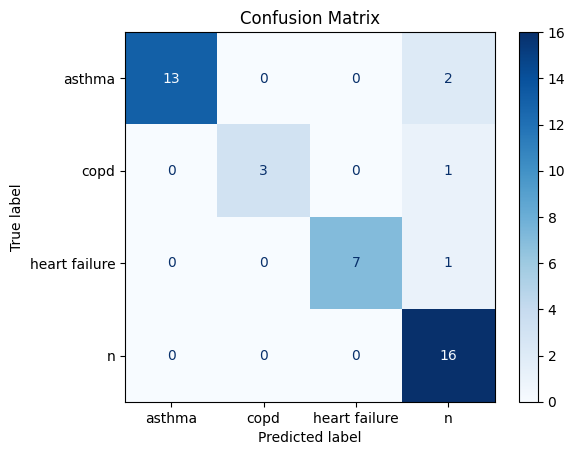

Sınıflandırma Raporu:

               precision    recall  f1-score   support

       asthma       1.00      0.87      0.93        15
         copd       1.00      0.75      0.86         4
heart failure       1.00      0.88      0.93         8
            n       0.80      1.00      0.89        16

     accuracy                           0.91        43
    macro avg       0.95      0.87      0.90        43
 weighted avg       0.93      0.91      0.91        43



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np

# Test seti tahminleri
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Sınıflandırma Raporu
print("Sınıflandırma Raporu:\n")
print(classification_report(y_true, y_pred, target_names=[str(label) for label in unique_labels]))


# 4 sınıflı FCNN

In [ ]:
# One-hot kodlanmış etiketleri sınıf indekslerine dönüştür
y_train_indices = np.argmax(y_train, axis=1)

# Sınıf indekslerini kullanarak sınıf ağırlıklarını hesapla
class_weights = compute_class_weight(class_weight='balanced',
                                    classes=np.unique(y_train_indices),
                                    y=y_train_indices)

# Sınıf ağırlıklarını bir sözlüğe dönüştür
class_weight_dict = dict(enumerate(class_weights))

In [ ]:
# FCNN Modelinin oluşturulması
model = Sequential()

# 1. Evrişim Katmanı
model.add(Input(shape=(40, max_length, 1)))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

# 2. Evrişim Katmanı
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Düzleştirme (Flattening)
model.add(Flatten())

# Tam Bağlantılı Katmanlar
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5)) # Dropout eklendi
model.add(Dense(4, activation='softmax')) # 4 çıkış sınıfı

# Modelin derlenmesi
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 40, 751, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 20, 375, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 18, 373, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 9, 186, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 107136)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │    13,713,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,732,868 (52.39 MB)

 Trainable params: 13,732,868 (52.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Verileri yeniden şekillendirme
X_train = X_train.reshape(X_train.shape[0], 40, max_length, 1)
X_val = X_val.reshape(X_val.shape[0], 40, max_length, 1)
X_test = X_test.reshape(X_test.shape[0], 40, max_length, 1)

# Modelin eğitimi
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping],
                    class_weight=class_weight_dict)



Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.2483 - loss: 2.3952 - val_accuracy: 0.1429 - val_loss: 1.4584
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.2541 - loss: 1.4487 - val_accuracy: 0.4286 - val_loss: 1.3407
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.4883 - loss: 1.3330 - val_accuracy: 0.6667 - val_loss: 1.3307
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.4730 - loss: 1.3041 - val_accuracy: 0.5952 - val_loss: 1.2965
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5296 - loss: 1.3243 - val_accuracy: 0.4762 - val_loss: 1.1982
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5572 - loss: 1.1413 - val_accuracy: 0.7381 - val_loss: 1.1730
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.6053 - loss: 1.0301 - val_accuracy: 0.6905 - val_loss: 1.0570
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6200 - loss: 0.9865 - val_accuracy: 0.5000 - val_loss: 1.1093


In [ ]:
# Modelin değerlendirilmesi
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Kaybı: {loss:.4f}")
print(f"Test Doğruluğu: {accuracy:.4f}")

Test Kaybı: 0.1849
Test Doğruluğu: 0.9535


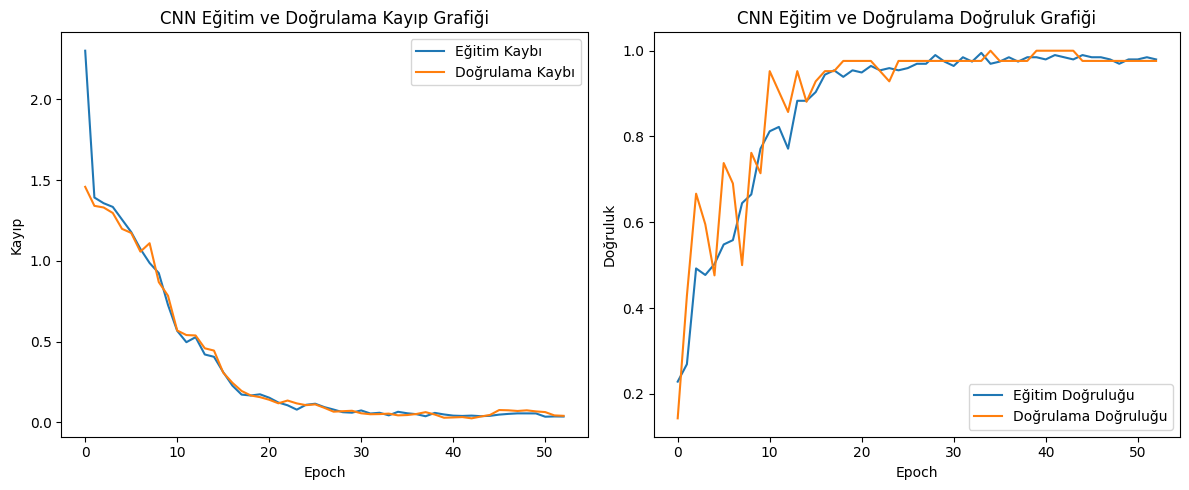

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Kayıp grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.title('CNN Eğitim ve Doğrulama Kayıp Grafiği')
plt.legend()

# Doğruluk grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.title('CNN Eğitim ve Doğrulama Doğruluk Grafiği')
plt.legend()

plt.tight_layout()
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step


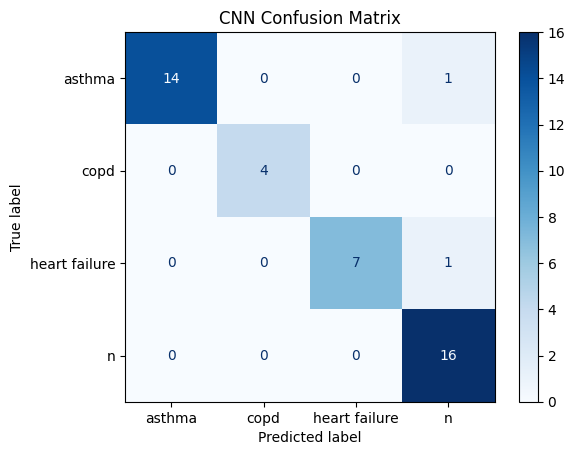

Sınıflandırma Raporu:

               precision    recall  f1-score   support

       asthma       1.00      0.93      0.97        15
         copd       1.00      1.00      1.00         4
heart failure       1.00      0.88      0.93         8
            n       0.89      1.00      0.94        16

     accuracy                           0.95        43
    macro avg       0.97      0.95      0.96        43
 weighted avg       0.96      0.95      0.95        43



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np

# Tahminler
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('CNN Confusion Matrix')
plt.show()

# Sınıflandırma Raporu
print("Sınıflandırma Raporu:\n")
print(classification_report(y_true, y_pred, target_names=[str(label) for label in unique_labels]))


# 4 Sınıflı makine öğrenmesi


In [ ]:
import os
import numpy as np
import torch
import torchaudio
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- 1. Dosya yolları ---
train_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4_clean"
val_dir   = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/val4"
test_dir  = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/test4"

train_files = [os.path.join(train_dir,f) for f in os.listdir(train_dir) if f.endswith(".wav")]
val_files   = [os.path.join(val_dir,f) for f in os.listdir(val_dir) if f.endswith(".wav")]
test_files  = [os.path.join(test_dir,f) for f in os.listdir(test_dir) if f.endswith(".wav")]

# --- 2. Etiket çıkar ---
def extract_labels(file_list):
    labels = []
    for file_path in file_list:
        fname = os.path.basename(file_path).lower()
        if "_n,n," in fname:
            labels.append(0)
        elif "asthma" in fname:
            labels.append(1)
        elif "copd" in fname:
            labels.append(2)
        elif "heart failure" in fname:
            labels.append(3)
        else:
            print(f"Bilinmeyen etiket: {fname}")
            labels.append(-1)  # unknown
    return np.array(labels)

y_train = extract_labels(train_files)
y_val   = extract_labels(val_files)
y_test  = extract_labels(test_files)

# --- 3. MFCC çıkar ve mean+std özetle ---
def extract_mfcc_mean_std(file_list, n_mfcc=40):
    features_list = []
    for file_path in file_list:
        try:
            waveform, sample_rate = torchaudio.load(file_path)
            mfcc_transform = torchaudio.transforms.MFCC(
                sample_rate=sample_rate,
                n_mfcc=n_mfcc,
                melkwargs={"n_fft":400, "hop_length":160, "n_mels":n_mfcc}
            )
            mfcc = mfcc_transform(waveform).squeeze(0).numpy()  # (n_mfcc, time_frames)
            # Mean + std → feature vektörü
            features = np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])
            features_list.append(features)
        except Exception as e:
            print(f"Hata oluştu: {file_path} - {e}")
    return np.array(features_list)  # (num_samples, n_mfcc*2)

X_train = extract_mfcc_mean_std(train_files)
X_val   = extract_mfcc_mean_std(val_files)
X_test  = extract_mfcc_mean_std(test_files)

print("X shapes:", X_train.shape, X_val.shape, X_test.shape)
print("y shapes:", y_train.shape, y_val.shape, y_test.shape)

# --- 4. Modeller ---
models = {
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric="mlogloss", random_state=42)
}

# --- 5. Eğitim ve Değerlendirme ---
for name, model in models.items():
    print(f"\n{name} Eğitiliyor...")
    model.fit(X_train, y_train)

    # Validation
    val_pred = model.predict(X_val)
    print(f"{name} Validation Accuracy: {accuracy_score(y_val, val_pred):.4f}")

    # Test
    test_pred = model.predict(X_test)
    print(f"{name} Test Accuracy: {accuracy_score(y_test, test_pred):.4f}")
    print(f"{name} Classification Report:\n", classification_report(y_test, test_pred))


X shapes: (197, 80) (42, 80) (43, 80)
y shapes: (197,) (42,) (43,)

SVM Eğitiliyor...
SVM Validation Accuracy: 0.3810
SVM Test Accuracy: 0.3721
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.37      1.00      0.54        16
           1       0.00      0.00      0.00        15
           2       0.00      0.00      0.00         4
           3       0.00      0.00      0.00         8

    accuracy                           0.37        43
   macro avg       0.09      0.25      0.14        43
weighted avg       0.14      0.37      0.20        43


RandomForest Eğitiliyor...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


RandomForest Validation Accuracy: 0.6190
RandomForest Test Accuracy: 0.6279
RandomForest Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.94      0.71        16
           1       0.69      0.73      0.71        15
           2       0.00      0.00      0.00         4
           3       1.00      0.12      0.22         8

    accuracy                           0.63        43
   macro avg       0.57      0.45      0.41        43
weighted avg       0.64      0.63      0.55        43


XGBoost Eğitiliyor...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/xgboost/t

XGBoost Validation Accuracy: 0.7143
XGBoost Test Accuracy: 0.6977
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.88      0.74        16
           1       0.77      0.67      0.71        15
           2       1.00      0.50      0.67         4
           3       0.67      0.50      0.57         8

    accuracy                           0.70        43
   macro avg       0.77      0.64      0.67        43
weighted avg       0.72      0.70      0.69        43




SVM Eğitiliyor...
SVM Validation Accuracy: 0.3810
SVM Test Accuracy: 0.3721
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.37      1.00      0.54        16
           1       0.00      0.00      0.00        15
           2       0.00      0.00      0.00         4
           3       0.00      0.00      0.00         8

    accuracy                           0.37        43
   macro avg       0.09      0.25      0.14        43
weighted avg       0.14      0.37      0.20        43



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


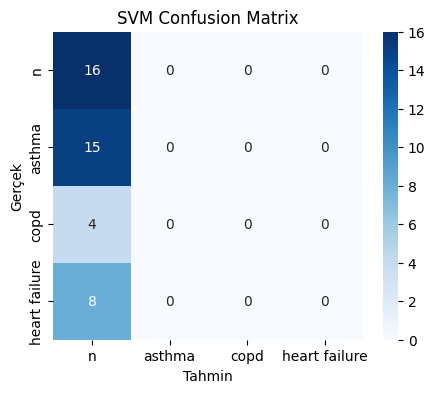


RandomForest Eğitiliyor...
RandomForest Validation Accuracy: 0.6190
RandomForest Test Accuracy: 0.6279
RandomForest Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.94      0.71        16
           1       0.69      0.73      0.71        15
           2       0.00      0.00      0.00         4
           3       1.00      0.12      0.22         8

    accuracy                           0.63        43
   macro avg       0.57      0.45      0.41        43
weighted avg       0.64      0.63      0.55        43



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


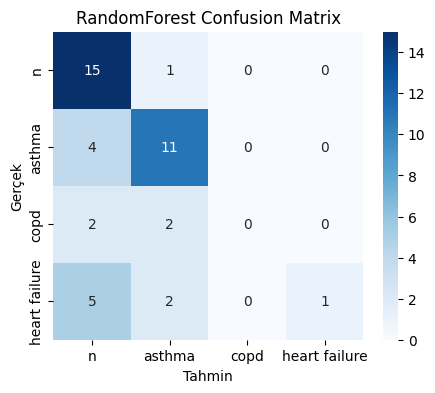


XGBoost Eğitiliyor...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:36:55] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Validation Accuracy: 0.7143
XGBoost Test Accuracy: 0.6977
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.88      0.74        16
           1       0.77      0.67      0.71        15
           2       1.00      0.50      0.67         4
           3       0.67      0.50      0.57         8

    accuracy                           0.70        43
   macro avg       0.77      0.64      0.67        43
weighted avg       0.72      0.70      0.69        43



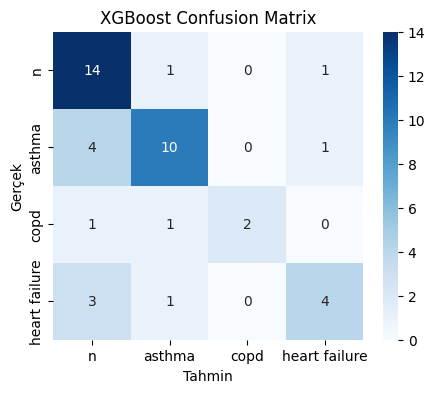

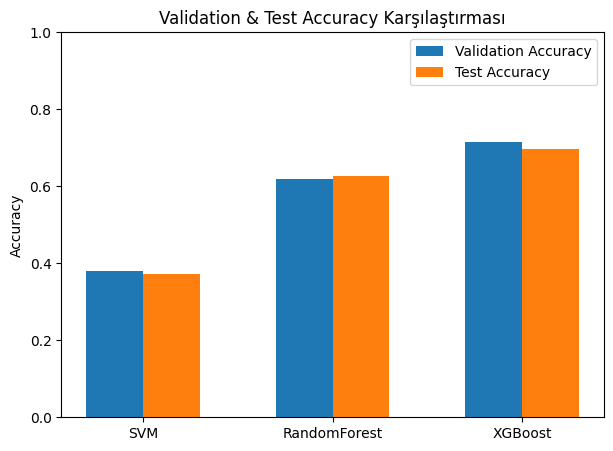

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# --- 1. Modeller ---
models = {
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric="mlogloss", random_state=42)
}

# --- 2. Eğitim + Değerlendirme ---
results = {}

for name, model in models.items():
    print(f"\n{name} Eğitiliyor...")
    model.fit(X_train, y_train)

    # Validation
    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)

    # Test
    test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)

    results[name] = {"val_acc": val_acc, "test_acc": test_acc, "test_pred": test_pred}

    print(f"{name} Validation Accuracy: {val_acc:.4f}")
    print(f"{name} Test Accuracy: {test_acc:.4f}")
    print(f"{name} Classification Report:\n", classification_report(y_test, test_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, test_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["n","asthma","copd","heart failure"],
                yticklabels=["n","asthma","copd","heart failure"])
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel("Gerçek")
    plt.xlabel("Tahmin")
    plt.show()

# --- 3. Doğruluk Grafiği ---
plt.figure(figsize=(7,5))
names = list(results.keys())
val_accs = [results[n]["val_acc"] for n in names]
test_accs = [results[n]["test_acc"] for n in names]

plt.bar(np.arange(len(names)) - 0.15, val_accs, width=0.3, label="Validation Accuracy")
plt.bar(np.arange(len(names)) + 0.15, test_accs, width=0.3, label="Test Accuracy")
plt.xticks(np.arange(len(names)), names)
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Validation & Test Accuracy Karşılaştırması")
plt.legend()
plt.show()


In [ ]:
!pip install imbalanced-learn


In [ ]:
from imblearn.over_sampling import SMOTE

# SMOTE ile sadece eğitim verisi
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Önce:", np.bincount(y_train))
print("Sonra:", np.bincount(y_train_res))



Önce: [73 67 19 38]
Sonra: [73 73 73 73]


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 4.5 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    class_weights='Balanced',  # Azınlık sınıflar için ağırlık
    verbose=100
)


In [ ]:
from collections import Counter
counter = Counter(y_train_res)
print(counter)  # örn: Counter({0: 73, 1:73, 2:73, 3:73})


Counter({np.int64(3): 73, np.int64(1): 73, np.int64(2): 73, np.int64(0): 73})


In [ ]:
# Klasik formül: weight_i = max_count / count_i
max_count = max(counter.values())
class_weights = [max_count / counter[i] for i in range(len(counter))]
print(class_weights)  # örn: [1.0, 1.0, 1.0, 1.0] (SMOTE ile eşitlendik, artık eşit)


[1.0, 1.0, 1.0, 1.0]


In [ ]:
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    class_weights=class_weights,  # artık liste
    verbose=100,
    random_state=42
)


Önce: [73 67 19 38]
Sonra: [73 73 73 73]

RandomForest Eğitiliyor...
RandomForest Validation Accuracy: 0.6429
RandomForest Test Accuracy: 0.6512
RandomForest Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.94      0.79        16
           1       0.73      0.53      0.62        15
           2       0.25      0.25      0.25         4
           3       0.67      0.50      0.57         8

    accuracy                           0.65        43
   macro avg       0.58      0.56      0.56        43
weighted avg       0.65      0.65      0.64        43



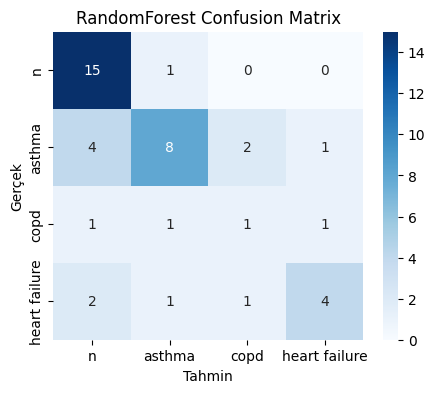


kNN Eğitiliyor...
kNN Validation Accuracy: 0.3571
kNN Test Accuracy: 0.4884
kNN Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.50      0.59        16
           1       0.67      0.40      0.50        15
           2       0.27      1.00      0.42         4
           3       0.38      0.38      0.38         8

    accuracy                           0.49        43
   macro avg       0.51      0.57      0.47        43
weighted avg       0.60      0.49      0.50        43



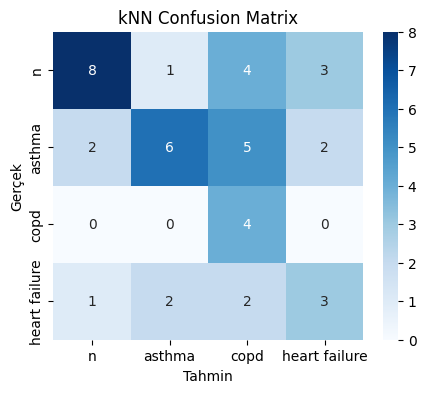


CatBoost Eğitiliyor...
0:	learn: 1.3500543	total: 139ms	remaining: 1m 9s
100:	learn: 0.3286313	total: 8.48s	remaining: 33.5s
200:	learn: 0.1556922	total: 14.9s	remaining: 22.2s
300:	learn: 0.1030914	total: 23.2s	remaining: 15.3s
400:	learn: 0.0795844	total: 34.7s	remaining: 8.55s
499:	learn: 0.0670328	total: 41s	remaining: 0us
CatBoost Validation Accuracy: 0.6905
CatBoost Test Accuracy: 0.6279
CatBoost Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.88      0.76        16
           1       0.64      0.60      0.62        15
           2       0.00      0.00      0.00         4
           3       0.57      0.50      0.53         8

    accuracy                           0.63        43
   macro avg       0.47      0.49      0.48        43
weighted avg       0.58      0.63      0.60        43



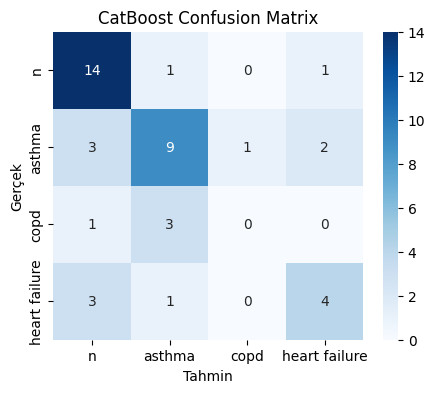

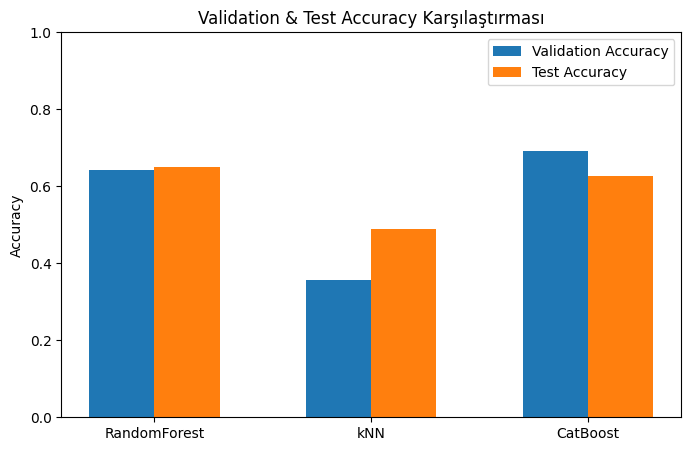

In [ ]:
# Gerekli kütüphaneler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier

# --- 1. SMOTE ile eğitim setini dengele ---
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Önce:", np.bincount(y_train))
print("Sonra:", np.bincount(y_train_res))

# --- 2. Modeller ---
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "CatBoost": CatBoostClassifier(
        iterations=500,
        learning_rate=0.1,
        depth=6,
        verbose=100,
        random_state=42
    )
}

results = {}

# --- 3. Eğitim ve Değerlendirme ---
for name, model in models.items():
    print(f"\n{name} Eğitiliyor...")
    model.fit(X_train_res, y_train_res)

    # Validation tahmini
    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)

    # Test tahmini
    test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)

    # Sonuçları kaydet
    results[name] = {
        "val_acc": val_acc,
        "test_acc": test_acc,
        "val_pred": val_pred,
        "test_pred": test_pred
    }

    print(f"{name} Validation Accuracy: {val_acc:.4f}")
    print(f"{name} Test Accuracy: {test_acc:.4f}")
    print(f"{name} Classification Report:\n", classification_report(y_test, test_pred, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, test_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["n","asthma","copd","heart failure"],
                yticklabels=["n","asthma","copd","heart failure"])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Tahmin")
    plt.ylabel("Gerçek")
    plt.show()

# --- 4. Doğruluk Karşılaştırması ---
plt.figure(figsize=(8,5))
names = list(results.keys())
val_accs = [results[n]["val_acc"] for n in names]
test_accs = [results[n]["test_acc"] for n in names]

plt.bar(np.arange(len(names)) - 0.15, val_accs, width=0.3, label="Validation Accuracy")
plt.bar(np.arange(len(names)) + 0.15, test_accs, width=0.3, label="Test Accuracy")
plt.xticks(np.arange(len(names)), names)
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Validation & Test Accuracy Karşılaştırması")
plt.legend()
plt.show()


In [ ]:
# Gerekli kütüphaneler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# --- 1. SMOTE ile eğitim setini dengele ---
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Önce:", np.bincount(y_train))
print("Sonra:", np.bincount(y_train_res))

# --- 2. Modeller ---
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "CatBoost": CatBoostClassifier(
        iterations=500,
        learning_rate=0.1,
        depth=6,
        verbose=100,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        use_label_encoder=False,
        eval_metric="mlogloss",
        random_state=42
    )
}

results = {}

# --- 3. Eğitim ve Değerlendirme ---
for name, model in models.items():
    print(f"\n{name} Eğitiliyor...")
    model.fit(X_train_res, y_train_res)

    # Validation tahmini
    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)

    # Test tahmini
    test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)

    # Sonuçları kaydet
    results[name] = {
        "val_acc": val_acc,
        "test_acc": test_acc,
        "val_pred": val_pred,
        "test_pred": test_pred
    }

    print(f"{name} Validation Accuracy: {val_acc:.4f}")
    print(f"{name} Test Accuracy: {test_acc:.4f}")
    print(f"{name} Classification Report:\n", classification_report(y_test, test_pred, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, test_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["n","asthma","copd","heart failure"],
                yticklabels=["n","asthma","copd","heart failure"])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Tahmin")
    plt.ylabel("Gerçek")
    plt.show()

# --- 4. Doğruluk Karşılaştırması ---
plt.figure(figsize=(9,5))
names = list(results.keys())
val_accs = [results[n]["val_acc"] for n in names]
test_accs = [results[n]["test_acc"] for n in names]

plt.bar(np.arange(len(names)) - 0.15, val_accs, width=0.3, label="Validation Accuracy")
plt.bar(np.arange(len(names)) + 0.15, test_accs, width=0.3, label="Test Accuracy")
plt.xticks(np.arange(len(names)), names)
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Validation & Test Accuracy Karşılaştırması")
plt.legend()
plt.show()


In [ ]:
import os

train_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4_clean"
val_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/val4"
test_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/test4"

train_files = [f for f in os.listdir(train_dir) if f.endswith('.wav')]
val_files   = [f for f in os.listdir(val_dir) if f.endswith('.wav')]
test_files  = [f for f in os.listdir(test_dir) if f.endswith('.wav')]

print("Train dosya sayısı:", len(train_files))
print("Validation dosya sayısı:", len(val_files))
print("Test dosya sayısı:", len(test_files))


Train dosya sayısı: 197
Validation dosya sayısı: 42
Test dosya sayısı: 43


In [ ]:
train_labels = extract_labels(train_files)
val_labels   = extract_labels(val_files)
test_labels  = extract_labels(test_files)

# Kaç tane her sınıftan var kontrol et
from collections import Counter
print("Train etiket dağılımı:", Counter(train_labels))
print("Validation etiket dağılımı:", Counter(val_labels))
print("Test etiket dağılımı:", Counter(test_labels))


Train etiket dağılımı: Counter({np.int64(0): 73, np.int64(1): 67, np.int64(3): 38, np.int64(2): 19})
Validation etiket dağılımı: Counter({np.int64(0): 16, np.int64(1): 14, np.int64(3): 8, np.int64(2): 4})
Test etiket dağılımı: Counter({np.int64(0): 16, np.int64(1): 15, np.int64(3): 8, np.int64(2): 4})


In [ ]:
for i in range(5):
    print(train_files[i], "->", train_labels[i])


DP14_Heart Failure,C,A R M,54,M.wav -> 3
EP35_Asthma,E W,A R L,38,M.wav -> 1
DP101_Asthma,E W,P L M,12,F.wav -> 1
BP25_copd,E W,P L L,76,M.wav -> 2
DP32_N,N,A R L,30,M.wav -> 0


In [ ]:
import torchaudio
import numpy as np
import os

def extract_mfcc(file_list, n_mfcc=40):
    mfcc_list = []
    for file_path in file_list:
        try:
            waveform, sample_rate = torchaudio.load(file_path)

            mfcc_transform = torchaudio.transforms.MFCC(
                sample_rate=sample_rate,
                n_mfcc=n_mfcc,
                melkwargs={"n_fft": 400, "hop_length": 160, "n_mels": n_mfcc}
            )

            mfcc = mfcc_transform(waveform)  # (channel, n_mfcc, time_frames)
            mfcc = mfcc.mean(dim=0)          # Kanal ortalaması → (n_mfcc, time_frames)
            mfcc = mfcc.numpy()

            # Ortalama ve std ile feature özetini al
            mfcc_mean = np.mean(mfcc, axis=1)
            mfcc_std  = np.std(mfcc, axis=1)
            mfcc_feature = np.concatenate([mfcc_mean, mfcc_std])  # (n_mfcc*2,)
            mfcc_list.append(mfcc_feature)

        except Exception as e:
            print(f"Hata oluştu: {file_path} - {e}")

    return np.array(mfcc_list)

# --- MFCC çıkarımı ---
X_train = extract_mfcc([os.path.join(train_dir, f) for f in train_files])
X_val   = extract_mfcc([os.path.join(val_dir, f) for f in val_files])
X_test  = extract_mfcc([os.path.join(test_dir, f) for f in test_files])

# Etiketler
y_train = np.array(train_labels)
y_val   = np.array(val_labels)
y_test  = np.array(test_labels)

print("X shapes:", X_train.shape, X_val.shape, X_test.shape)
print("y shapes:", y_train.shape, y_val.shape, y_test.shape)


/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

X shapes: (197, 80) (42, 80) (43, 80)
y shapes: (197,) (42,) (43,)


Önce: [73 67 19 38]
Sonra: [73 73 73 73]

RandomForest Eğitiliyor...
RandomForest Validation Accuracy: 0.6429
RandomForest Test Accuracy: 0.6512
RandomForest Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.94      0.79        16
           1       0.73      0.53      0.62        15
           2       0.25      0.25      0.25         4
           3       0.67      0.50      0.57         8

    accuracy                           0.65        43
   macro avg       0.58      0.56      0.56        43
weighted avg       0.65      0.65      0.64        43



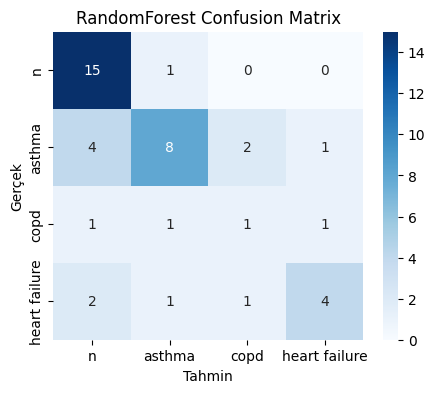


kNN Eğitiliyor...
kNN Validation Accuracy: 0.3571
kNN Test Accuracy: 0.4884
kNN Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.50      0.59        16
           1       0.67      0.40      0.50        15
           2       0.27      1.00      0.42         4
           3       0.38      0.38      0.38         8

    accuracy                           0.49        43
   macro avg       0.51      0.57      0.47        43
weighted avg       0.60      0.49      0.50        43



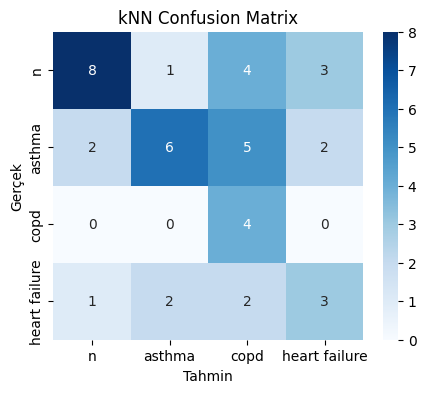


CatBoost Eğitiliyor...
0:	learn: 1.3500543	total: 95.5ms	remaining: 47.7s
100:	learn: 0.3205052	total: 7.26s	remaining: 28.7s
200:	learn: 0.1520069	total: 15s	remaining: 22.3s
300:	learn: 0.1032128	total: 22.4s	remaining: 14.8s
400:	learn: 0.0789541	total: 29.8s	remaining: 7.37s
499:	learn: 0.0679812	total: 37.7s	remaining: 0us
CatBoost Validation Accuracy: 0.6905
CatBoost Test Accuracy: 0.6279
CatBoost Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.94      0.77        16
           1       0.62      0.53      0.57        15
           2       0.00      0.00      0.00         4
           3       0.67      0.50      0.57         8

    accuracy                           0.63        43
   macro avg       0.48      0.49      0.48        43
weighted avg       0.58      0.63      0.59        43



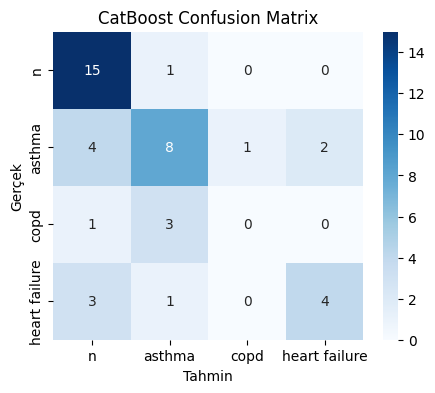


XGBoost Eğitiliyor...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [13:10:25] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Validation Accuracy: 0.7143
XGBoost Test Accuracy: 0.6512
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.94      0.81        16
           1       0.69      0.60      0.64        15
           2       0.00      0.00      0.00         4
           3       0.57      0.50      0.53         8

    accuracy                           0.65        43
   macro avg       0.49      0.51      0.50        43
weighted avg       0.61      0.65      0.63        43



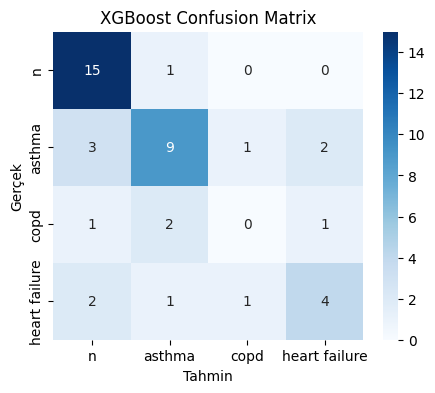

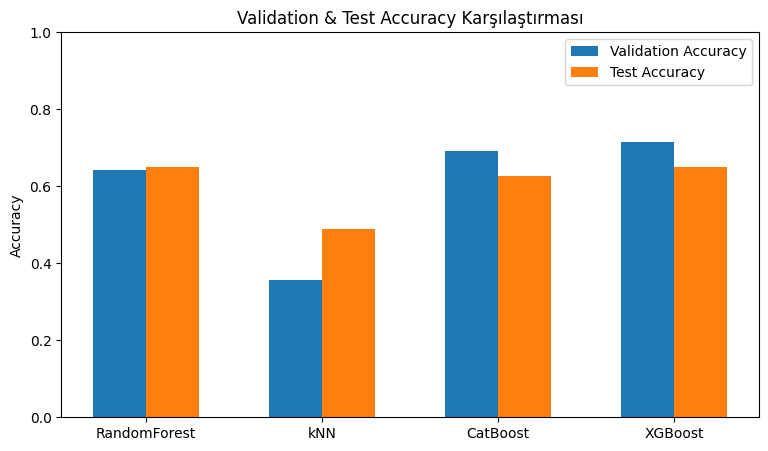

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. SMOTE ile eğitim setini dengele ---
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Önce:", np.bincount(y_train))
print("Sonra:", np.bincount(y_train_res))  # Artık tüm sınıflar eşit

# --- 2. Modeller ---
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "CatBoost": CatBoostClassifier(
        iterations=500,
        learning_rate=0.1,
        depth=6,
        verbose=100,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        use_label_encoder=False,
        eval_metric="mlogloss",
        random_state=42
    )
}

results = {}

# --- 3. Eğitim ve Değerlendirme ---
for name, model in models.items():
    print(f"\n{name} Eğitiliyor...")
    model.fit(X_train_res, y_train_res)

    # Validation tahmini
    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)

    # Test tahmini
    test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)

    # Sonuçları kaydet
    results[name] = {
        "val_acc": val_acc,
        "test_acc": test_acc,
        "val_pred": val_pred,
        "test_pred": test_pred
    }

    print(f"{name} Validation Accuracy: {val_acc:.4f}")
    print(f"{name} Test Accuracy: {test_acc:.4f}")
    print(f"{name} Classification Report:\n", classification_report(y_test, test_pred, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, test_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["n","asthma","copd","heart failure"],
                yticklabels=["n","asthma","copd","heart failure"])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Tahmin")
    plt.ylabel("Gerçek")
    plt.show()

# --- 4. Doğruluk Karşılaştırması ---
plt.figure(figsize=(9,5))
names = list(results.keys())
val_accs = [results[n]["val_acc"] for n in names]
test_accs = [results[n]["test_acc"] for n in names]

plt.bar(np.arange(len(names)) - 0.15, val_accs, width=0.3, label="Validation Accuracy")
plt.bar(np.arange(len(names)) + 0.15, test_accs, width=0.3, label="Test Accuracy")
plt.xticks(np.arange(len(names)), names)
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Validation & Test Accuracy Karşılaştırması")
plt.legend()
plt.show()


# ML Sonuçları

Önce: [73 67 19 38]
Sonra: [73 73 73 73]

RandomForest Eğitiliyor...
RandomForest Validation Accuracy: 0.6429
RandomForest Test Accuracy: 0.6512
RandomForest Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.94      0.79        16
           1       0.73      0.53      0.62        15
           2       0.25      0.25      0.25         4
           3       0.67      0.50      0.57         8

    accuracy                           0.65        43
   macro avg       0.58      0.56      0.56        43
weighted avg       0.65      0.65      0.64        43



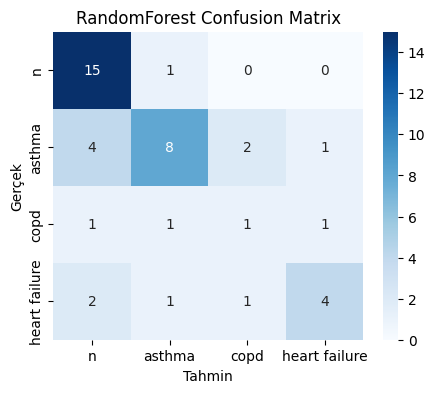


GradientBoosting Eğitiliyor...
GradientBoosting Validation Accuracy: 0.7619
GradientBoosting Test Accuracy: 0.6512
GradientBoosting Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.94      0.77        16
           1       0.69      0.60      0.64        15
           2       0.00      0.00      0.00         4
           3       0.67      0.50      0.57         8

    accuracy                           0.65        43
   macro avg       0.50      0.51      0.50        43
weighted avg       0.61      0.65      0.62        43



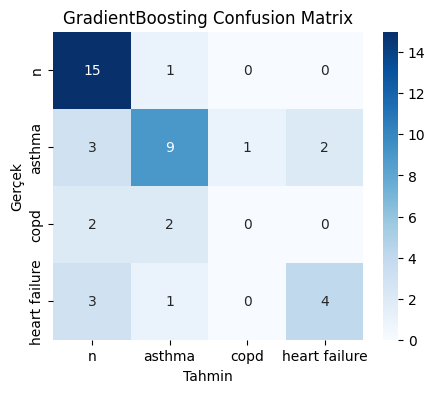


LightGBM Eğitiliyor...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000392 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7842
[LightGBM] [Info] Number of data points in the train set: 292, number of used features: 80
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


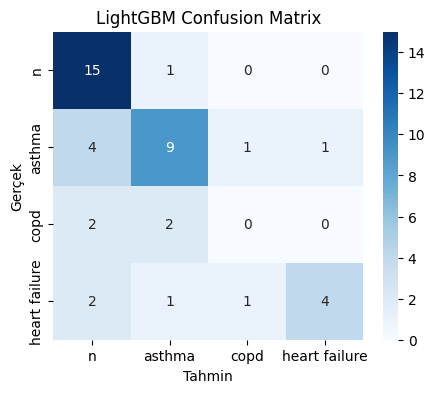


CatBoost Eğitiliyor...
0:	learn: 1.3500543	total: 90.5ms	remaining: 45.2s
100:	learn: 0.3205052	total: 6.51s	remaining: 25.7s
200:	learn: 0.1520069	total: 14.8s	remaining: 22s
300:	learn: 0.1032128	total: 21.3s	remaining: 14.1s
400:	learn: 0.0789541	total: 29.6s	remaining: 7.3s
499:	learn: 0.0679812	total: 35.9s	remaining: 0us
CatBoost Validation Accuracy: 0.6905
CatBoost Test Accuracy: 0.6279
CatBoost Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.94      0.77        16
           1       0.62      0.53      0.57        15
           2       0.00      0.00      0.00         4
           3       0.67      0.50      0.57         8

    accuracy                           0.63        43
   macro avg       0.48      0.49      0.48        43
weighted avg       0.58      0.63      0.59        43



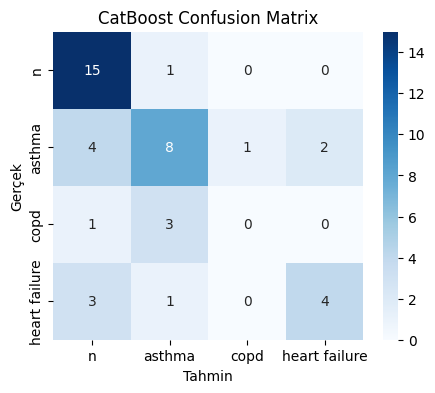


XGBoost Eğitiliyor...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [13:46:31] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Validation Accuracy: 0.7143
XGBoost Test Accuracy: 0.6512
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.94      0.81        16
           1       0.69      0.60      0.64        15
           2       0.00      0.00      0.00         4
           3       0.57      0.50      0.53         8

    accuracy                           0.65        43
   macro avg       0.49      0.51      0.50        43
weighted avg       0.61      0.65      0.63        43



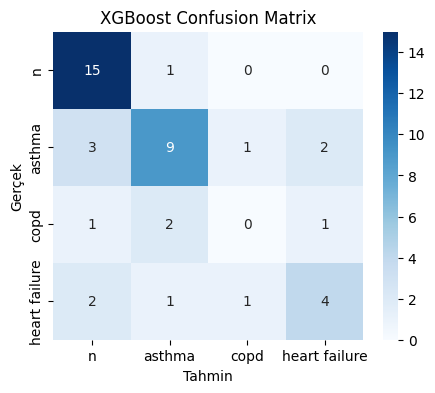

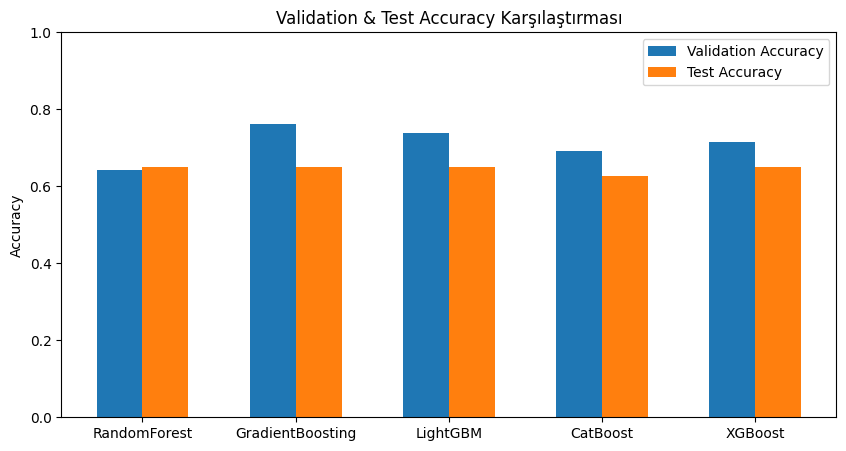

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. SMOTE ile eğitim setini dengele ---
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Önce:", np.bincount(y_train))
print("Sonra:", np.bincount(y_train_res))  # Tüm sınıflar eşitlenmiş

# --- 2. Modeller ---
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    "LightGBM": lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    "CatBoost": CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, verbose=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric="mlogloss", random_state=42)
}

results = {}

# --- 3. Eğitim ve Değerlendirme ---
for name, model in models.items():
    print(f"\n{name} Eğitiliyor...")
    model.fit(X_train_res, y_train_res)

    # Validation tahmini
    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)

    # Test tahmini
    test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)

    # Sonuçları kaydet
    results[name] = {
        "val_acc": val_acc,
        "test_acc": test_acc,
        "val_pred": val_pred,
        "test_pred": test_pred
    }

    print(f"{name} Validation Accuracy: {val_acc:.4f}")
    print(f"{name} Test Accuracy: {test_acc:.4f}")
    print(f"{name} Classification Report:\n", classification_report(y_test, test_pred, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, test_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["n","asthma","copd","heart failure"],
                yticklabels=["n","asthma","copd","heart failure"])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Tahmin")
    plt.ylabel("Gerçek")
    plt.show()

# --- 4. Doğruluk Karşılaştırması ---
plt.figure(figsize=(10,5))
names = list(results.keys())
val_accs = [results[n]["val_acc"] for n in names]
test_accs = [results[n]["test_acc"] for n in names]

plt.bar(np.arange(len(names)) - 0.15, val_accs, width=0.3, label="Validation Accuracy")
plt.bar(np.arange(len(names)) + 0.15, test_accs, width=0.3, label="Test Accuracy")
plt.xticks(np.arange(len(names)), names)
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Validation & Test Accuracy Karşılaştırması")
plt.legend()
plt.show()


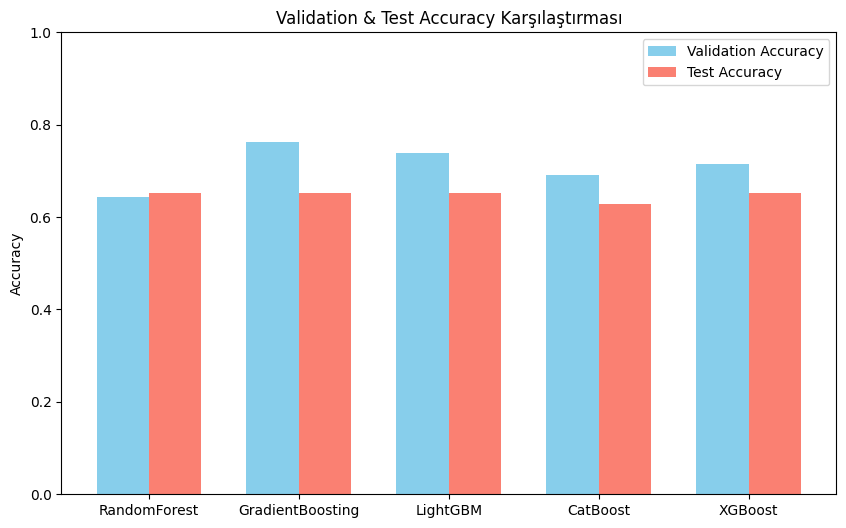

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Model isimleri ---
names = list(results.keys())
val_accs = [results[n]["val_acc"] for n in names]
test_accs = [results[n]["test_acc"] for n in names]

# --- 2. Doğruluk Grafiği ---
plt.figure(figsize=(10,6))
bar_width = 0.35
x = np.arange(len(names))

plt.bar(x - bar_width/2, val_accs, width=bar_width, label='Validation Accuracy', color='skyblue')
plt.bar(x + bar_width/2, test_accs, width=bar_width, label='Test Accuracy', color='salmon')

plt.xticks(x, names)
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.title('Validation & Test Accuracy Karşılaştırması')
plt.legend()
plt.show()


Önce: [73 67 19 38]
Sonra: [73 73 73 73]

RandomForest Eğitiliyor...
RandomForest Validation Accuracy: 0.6429
RandomForest Test Accuracy: 0.6512
RandomForest Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.94      0.79        16
           1       0.73      0.53      0.62        15
           2       0.25      0.25      0.25         4
           3       0.67      0.50      0.57         8

    accuracy                           0.65        43
   macro avg       0.58      0.56      0.56        43
weighted avg       0.65      0.65      0.64        43



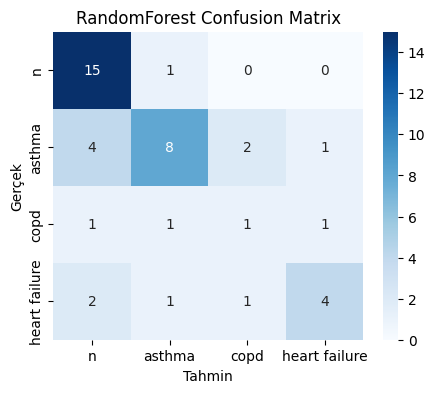


GradientBoosting Eğitiliyor...
GradientBoosting Validation Accuracy: 0.7619
GradientBoosting Test Accuracy: 0.6512
GradientBoosting Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.94      0.77        16
           1       0.69      0.60      0.64        15
           2       0.00      0.00      0.00         4
           3       0.67      0.50      0.57         8

    accuracy                           0.65        43
   macro avg       0.50      0.51      0.50        43
weighted avg       0.61      0.65      0.62        43



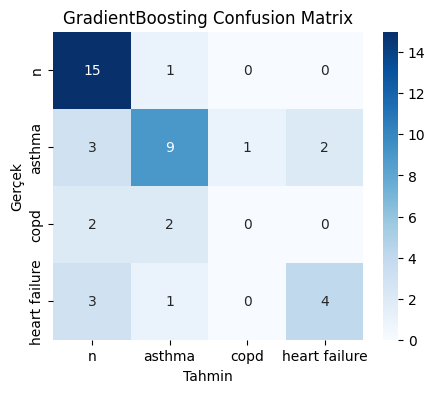


LightGBM Eğitiliyor...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000713 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7842
[LightGBM] [Info] Number of data points in the train set: 292, number of used features: 80
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


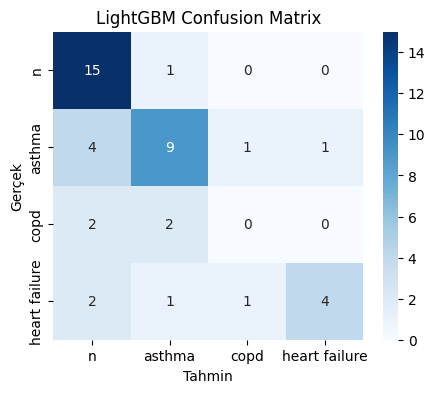


NaiveBayes Eğitiliyor...
NaiveBayes Validation Accuracy: 0.4762
NaiveBayes Test Accuracy: 0.4884
NaiveBayes Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.69      0.58        16
           1       0.70      0.47      0.56        15
           2       0.00      0.00      0.00         4
           3       0.43      0.38      0.40         8

    accuracy                           0.49        43
   macro avg       0.41      0.38      0.38        43
weighted avg       0.51      0.49      0.49        43



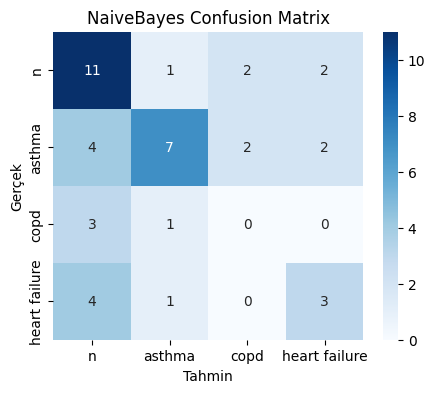


CatBoost Eğitiliyor...
0:	learn: 1.3500543	total: 98.6ms	remaining: 49.2s
100:	learn: 0.3205052	total: 6.58s	remaining: 26s
200:	learn: 0.1520069	total: 14.9s	remaining: 22.1s
300:	learn: 0.1032128	total: 21.3s	remaining: 14.1s
400:	learn: 0.0789541	total: 29.6s	remaining: 7.31s
499:	learn: 0.0679812	total: 36s	remaining: 0us
CatBoost Validation Accuracy: 0.6905
CatBoost Test Accuracy: 0.6279
CatBoost Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.94      0.77        16
           1       0.62      0.53      0.57        15
           2       0.00      0.00      0.00         4
           3       0.67      0.50      0.57         8

    accuracy                           0.63        43
   macro avg       0.48      0.49      0.48        43
weighted avg       0.58      0.63      0.59        43



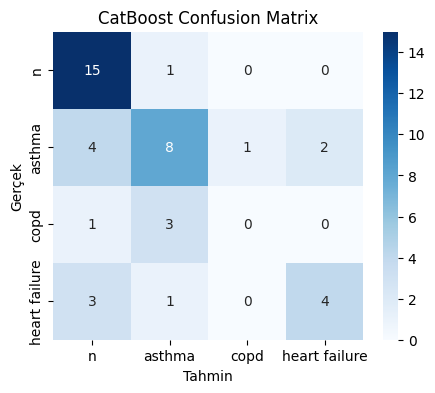


XGBoost Eğitiliyor...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [13:23:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Validation Accuracy: 0.7143
XGBoost Test Accuracy: 0.6512
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.94      0.81        16
           1       0.69      0.60      0.64        15
           2       0.00      0.00      0.00         4
           3       0.57      0.50      0.53         8

    accuracy                           0.65        43
   macro avg       0.49      0.51      0.50        43
weighted avg       0.61      0.65      0.63        43



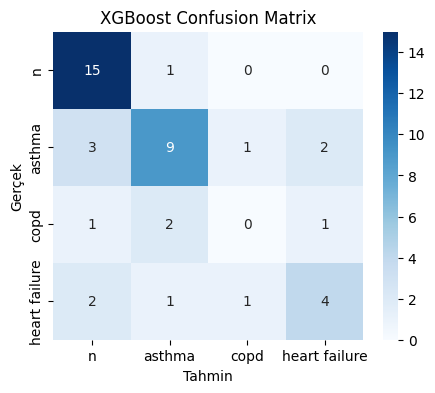

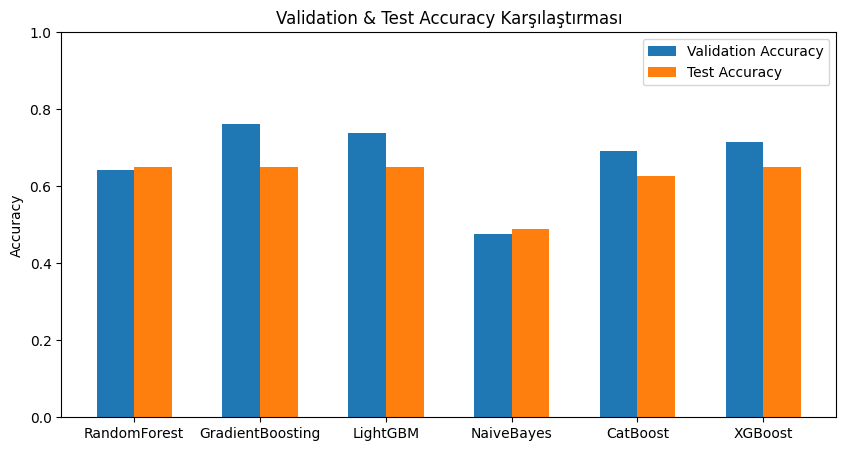

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. SMOTE ile eğitim setini dengele ---
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Önce:", np.bincount(y_train))
print("Sonra:", np.bincount(y_train_res))  # Tüm sınıflar eşitlenmiş

# --- 2. Modeller ---
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    "LightGBM": lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    "NaiveBayes": GaussianNB(),
    "CatBoost": CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, verbose=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric="mlogloss", random_state=42)
}

results = {}

# --- 3. Eğitim ve Değerlendirme ---
for name, model in models.items():
    print(f"\n{name} Eğitiliyor...")
    model.fit(X_train_res, y_train_res)

    # Validation tahmini
    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)

    # Test tahmini
    test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)

    # Sonuçları kaydet
    results[name] = {
        "val_acc": val_acc,
        "test_acc": test_acc,
        "val_pred": val_pred,
        "test_pred": test_pred
    }

    print(f"{name} Validation Accuracy: {val_acc:.4f}")
    print(f"{name} Test Accuracy: {test_acc:.4f}")
    print(f"{name} Classification Report:\n", classification_report(y_test, test_pred, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, test_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["n","asthma","copd","heart failure"],
                yticklabels=["n","asthma","copd","heart failure"])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Tahmin")
    plt.ylabel("Gerçek")
    plt.show()

# --- 4. Doğruluk Karşılaştırması ---
plt.figure(figsize=(10,5))
names = list(results.keys())
val_accs = [results[n]["val_acc"] for n in names]
test_accs = [results[n]["test_acc"] for n in names]

plt.bar(np.arange(len(names)) - 0.15, val_accs, width=0.3, label="Validation Accuracy")
plt.bar(np.arange(len(names)) + 0.15, test_accs, width=0.3, label="Test Accuracy")
plt.xticks(np.arange(len(names)), names)
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Validation & Test Accuracy Karşılaştırması")
plt.legend()
plt.show()


# FCNN model eğitimi

In [ ]:
# FCNN Modelinin oluşturulması
model = Sequential()

# 1. Evrişim Katmanı
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(40, max_length, 1))) # Giriş şekli (40, max_length, 1)
model.add(MaxPooling2D((2, 2)))

# 2. Evrişim Katmanı
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Düzleştirme (Flattening)
model.add(Flatten())

# Tam Bağlantılı Katmanlar
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5)) # Dropout eklendi
model.add(Dense(8, activation='softmax')) # 8 çıkış sınıfı

# Modelin derlenmesi
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Verileri yeniden şekillendirme
X_train = X_train.reshape(X_train.shape[0], 40, max_length, 1)
X_val = X_val.reshape(X_val.shape[0], 40, max_length, 1)
X_test = X_test.reshape(X_test.shape[0], 40, max_length, 1)

# Modelin eğitimi
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping],
                    class_weight=class_weight_dict)

# Modelin değerlendirilmesi
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Kaybı: {loss:.4f}")
print(f"Test Doğruluğu: {accuracy:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.1380 - loss: 8.4820 - val_accuracy: 0.0976 - val_loss: 2.9402
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.1355 - loss: 2.0017 - val_accuracy: 0.2439 - val_loss: 2.0205
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.3613 - loss: 1.9631 - val_accuracy: 0.2439 - val_loss: 1.8313
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.4806 - loss: 1.8137 - val_accuracy: 0.5366 - val_loss: 1.5629
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.4625 - loss: 1.1289 - val_accuracy: 0.5610 - val_loss: 1.4482
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6695 - loss: 0.8748 - val_accuracy: 0.7805 - val_loss: 0.9898
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7214 - loss: 0.6001 - val_accuracy: 0.6829 - val_loss: 0.9896
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.8176 - loss: 0.4388 - val_accuracy: 0.8780 - val_loss: 0.5440


# FCNN sonuçları

accuracy (Epoch sırasında)	Eğitim verisi üzerindeki doğruluk. (X_train)
val_accuracy	Doğrulama (validation) verisi üzerindeki doğruluk.
model.evaluate(X_test, y_test)	Test verisi üzerindeki doğruluk. (X_test)

Epoch 35:
accuracy:     0.9971   (eğitim verisindeki başarı)
val_accuracy: 0.9512   (doğrulama verisindeki başarı)
Test accuracy: 0.9559  (gerçek dünya verisi üzerindeki başarı)


Eğitimde aşırı yüksek (model ezberlemiş olabilir).
Validasyonda ve testte ise birbirine çok yakın (0.9512 vs 0.9559) → genelleme yeteneği güçlü bir model demektir.

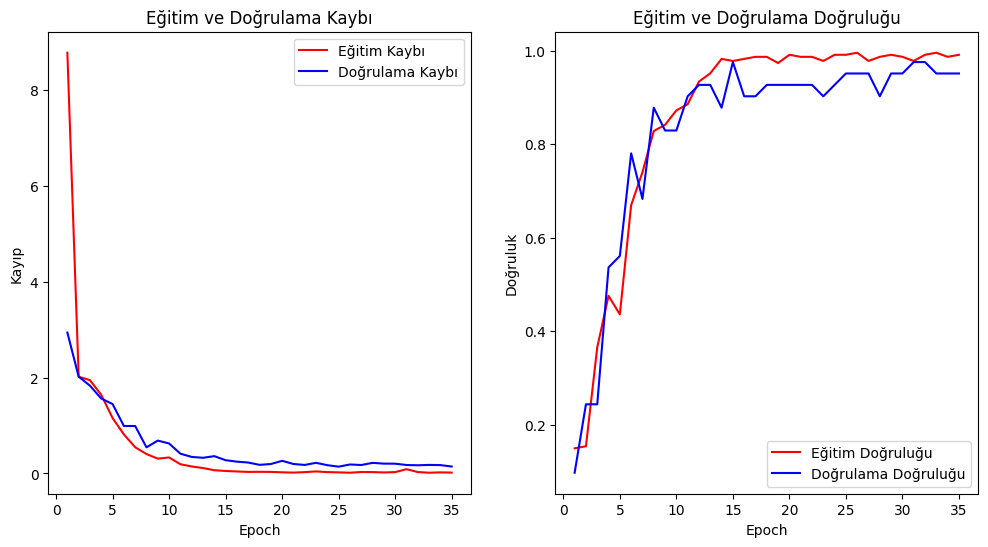

In [ ]:
# Eğitim geçmişinden kayıp ve doğruluk değerlerini al
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Epoch sayısı
epochs = range(1, len(train_loss) + 1)

# Kayıp grafiği
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'r', label='Eğitim Kaybı')
plt.plot(epochs, val_loss, 'b', label='Doğrulama Kaybı')
plt.title('Eğitim ve Doğrulama Kaybı')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.legend()

# Doğruluk grafiği
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, 'r', label='Eğitim Doğruluğu')
plt.plot(epochs, val_acc, 'b', label='Doğrulama Doğruluğu')
plt.title('Eğitim ve Doğrulama Doğruluğu')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()

plt.show()

In [ ]:
# En uzun zaman penceresinin uzunluğunu bulma
max_length = max([x.shape[2] for x in mfcc_features_list])

# Padding işlemi
def pad_mfcc(mfcc, max_length):
    # MFCC matrisini, en uzun zaman penceresinin uzunluğuna kadar sıfırlarla doldur
    padded_mfcc = torch.nn.functional.pad(mfcc, (0, max_length - mfcc.shape[2]))
    return padded_mfcc

# Tüm MFCC'leri padding ile hizalama
padded_mfcc_features_list = []
for mfcc in mfcc_features_list:
    padded_mfcc = pad_mfcc(mfcc, max_length)
    padded_mfcc_features_list.append(padded_mfcc)

# Padding uygulanmış MFCC'lerin boyutlarını yazdırma
for i, padded_mfcc in enumerate(padded_mfcc_features_list[:5]):  # İlk 5 dosya için
    print(f"File {i+1}: Padded MFCC Shape = {padded_mfcc.shape}")

File 1: Padded MFCC Shape = torch.Size([1, 40, 3817])
File 2: Padded MFCC Shape = torch.Size([1, 40, 3817])
File 3: Padded MFCC Shape = torch.Size([1, 40, 3817])
File 4: Padded MFCC Shape = torch.Size([1, 40, 3817])
File 5: Padded MFCC Shape = torch.Size([1, 40, 3817])


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(set(y))  # Sınıf sayısı
model = LungSoundCNN(num_classes=len(set(y))).to(device)



In [ ]:
from sklearn.model_selection import train_test_split

# X ve y olarak ayır
X = normalized_mfcc_features_list  # Özellikler (MFCC tensorları)
y = labels  # Etiketler (string veya integer)

# Eğitim ve doğrulama için böl (örneğin %80 eğitim, %20 doğrulama)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Dataset sınıfımızı kullanarak torch Dataset objeleri oluştur
train_dataset = LungSoundDataset(X_train, y_train)
val_dataset = LungSoundDataset(X_val, y_val)



In [ ]:
from torch.utils.data import DataLoader

train_dataset = LungSoundDataset(X_train, y_train)
test_dataset = LungSoundDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [ ]:
import torch.nn as nn
import torch.optim as optim

model = LungSoundCNN(num_classes=len(set(y))).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
# Tüm sınıfları belirle
class_names = sorted(list(set(labels)))  # Örneğin ['asthma', 'bron', 'copd', ...]

# String -> Index mapping
label_to_index = {label: idx for idx, label in enumerate(class_names)}

# Sayısal etiketleri üret
numeric_labels = [label_to_index[label] for label in labels]


In [ ]:
from sklearn.model_selection import train_test_split

# X ve y olarak ayır
X = normalized_mfcc_features_list  # Özellikler (MFCC tensorları)
y = labels # Etiketler (string veya integer)

# Eğitim ve doğrulama için böl (örneğin %80 eğitim, %20 doğrulama)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Dataset sınıfımızı kullanarak torch Dataset objeleri oluştur
train_dataset = LungSoundDataset(X_train, y_train)
val_dataset = LungSoundDataset(X_val, y_val)


In [ ]:
import os

folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files2"

for file_name in os.listdir(folder):
    if "_aug" in file_name and file_name.endswith(".wav"):
        os.remove(os.path.join(folder, file_name))
        print(f"Silindi: {file_name}")


Silindi: BP109_N,N,P L M,26,M_aug0.wav
Silindi: BP109_N,N,P L M,26,M_aug1.wav
Silindi: BP109_N,N,P L M,26,M_aug2.wav
Silindi: BP109_N,N,P L M,26,M_aug3.wav
Silindi: BP109_N,N,P L M,26,M_aug4.wav
Silindi: BP107_Asthma,E W,P L U,59,F_aug0.wav
Silindi: BP107_Asthma,E W,P L U,59,F_aug1.wav
Silindi: BP107_Asthma,E W,P L U,59,F_aug2.wav
Silindi: BP107_Asthma,E W,P L U,59,F_aug3.wav
Silindi: BP107_Asthma,E W,P L U,59,F_aug4.wav
Silindi: BP108_COPD,E W,P R L ,63,M_aug0.wav
Silindi: BP108_COPD,E W,P R L ,63,M_aug1.wav
Silindi: BP108_COPD,E W,P R L ,63,M_aug2.wav
Silindi: BP108_COPD,E W,P R L ,63,M_aug3.wav
Silindi: BP108_COPD,E W,P R L ,63,M_aug4.wav
Silindi: BP102_N,N,P L L,41,M_aug0.wav
Silindi: BP102_N,N,P L L,41,M_aug1.wav
Silindi: BP102_N,N,P L L,41,M_aug2.wav
Silindi: BP102_N,N,P L L,41,M_aug3.wav
Silindi: BP102_N,N,P L L,41,M_aug4.wav
Silindi: BP101_Asthma,E W,P L M,12,F_aug0.wav
Silindi: BP101_Asthma,E W,P L M,12,F_aug1.wav
Silindi: BP101_Asthma,E W,P L M,12,F_aug2.wav
Silindi: BP101_As

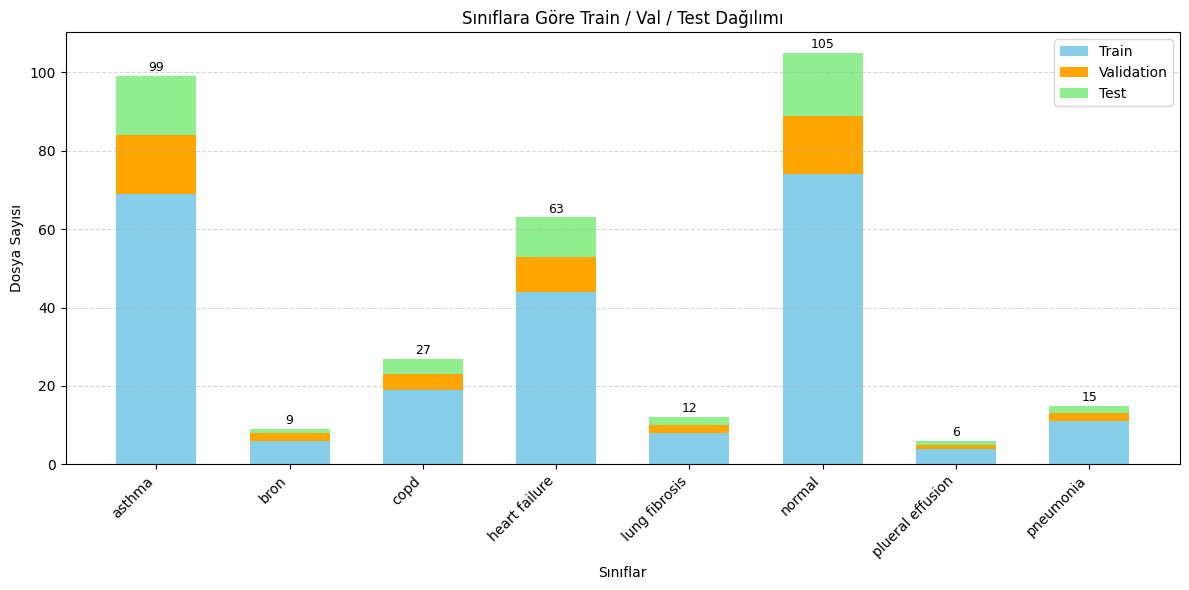

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# Train, Val, Test dağılımları
train_counts = Counter(train_labels)
val_counts = Counter(val_labels)
test_counts = Counter(test_labels)

# Tüm sınıfların birleşik kümesini oluştur
all_labels = sorted(set(train_counts.keys()) | set(val_counts.keys()) | set(test_counts.keys()))

# Her bir sınıf için train/val/test sayıları
train_vals = [train_counts[label] for label in all_labels]
val_vals = [val_counts[label] for label in all_labels]
test_vals = [test_counts[label] for label in all_labels]

# Grafik çizimi
x = np.arange(len(all_labels))
width = 0.6

plt.figure(figsize=(12, 6))
plt.bar(x, train_vals, width, label='Train', color='skyblue')
plt.bar(x, val_vals, width, bottom=train_vals, label='Validation', color='orange')
plt.bar(x, test_vals, width, bottom=np.array(train_vals) + np.array(val_vals), label='Test', color='lightgreen')

# Her barın üstüne toplam sayıyı yaz
for i in range(len(x)):
    total = train_vals[i] + val_vals[i] + test_vals[i]
    plt.text(x[i], total + 0.5, str(total), ha='center', va='bottom', fontsize=9)

plt.xticks(x, all_labels, rotation=45, ha='right')
plt.xlabel('Sınıflar')
plt.ylabel('Dosya Sayısı')
plt.title('Sınıflara Göre Train / Val / Test Dağılımı')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


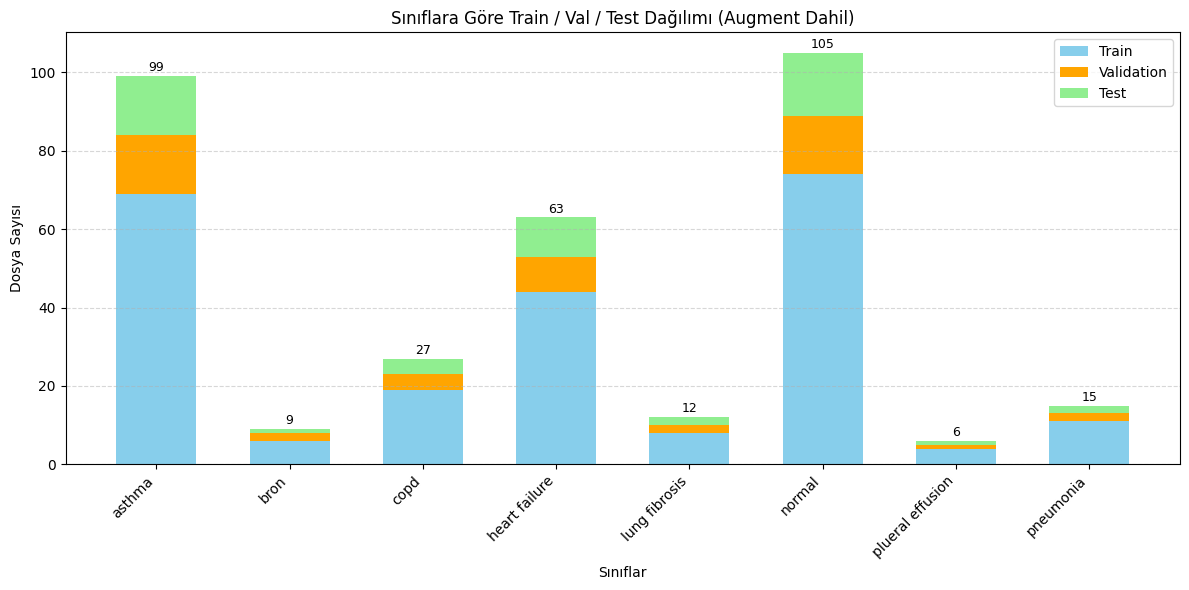

In [ ]:
import os
import re
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

def extract_label_from_filename(filename):
    match = re.match(r'^([BED]P\d+)_([^,]+),([^,]+),([^,]+),(\d+),?(M|F)(?:_aug\d+)?\.wav$', filename)
    if match:
        diagnosis = match.group(2).strip().lower()
        if 'asthma and lung fibrosis' in diagnosis:
            return 'asthma'
        elif 'heart failure + copd' in diagnosis or 'heart failure + lung fibrosis' in diagnosis:
            return 'heart failure'
        elif 'asthma' in diagnosis:
            return 'asthma'
        elif 'bron' in diagnosis:
            return 'bron'
        elif 'copd' in diagnosis:
            return 'copd'
        elif 'heart failure' in diagnosis:
            return 'heart failure'
        elif 'lung fibrosis' in diagnosis:
            return 'lung fibrosis'
        elif 'pleural effusion' in diagnosis or 'plueral effusion' in diagnosis:
            return 'plueral effusion'
        elif 'pneumonia' in diagnosis:
            return 'pneumonia'
        elif diagnosis == 'n':
            return 'normal'
    return None

def count_labels_from_directory(directory):
    label_counter = Counter()
    for filename in os.listdir(directory):
        if filename.endswith('.wav'):
            label = extract_label_from_filename(filename)
            if label:
                label_counter[label] += 1
    return label_counter

# Tüm klasörlerden sayımları al
train_counts = count_labels_from_directory("dataset/train")
val_counts = count_labels_from_directory("dataset/val")
test_counts = count_labels_from_directory("dataset/test")

# Sınıf etiketlerinin birleşimini al
all_labels = sorted(set(train_counts.keys()) | set(val_counts.keys()) | set(test_counts.keys()))

# Her bir sınıf için dağılımları çıkar
train_vals = [train_counts[label] for label in all_labels]
val_vals = [val_counts[label] for label in all_labels]
test_vals = [test_counts[label] for label in all_labels]

# Grafik çizimi
x = np.arange(len(all_labels))
width = 0.6

plt.figure(figsize=(12, 6))
plt.bar(x, train_vals, width, label='Train', color='skyblue')
plt.bar(x, val_vals, width, bottom=train_vals, label='Validation', color='orange')
plt.bar(x, test_vals, width, bottom=np.array(train_vals) + np.array(val_vals), label='Test', color='lightgreen')

for i in range(len(x)):
    total = train_vals[i] + val_vals[i] + test_vals[i]
    plt.text(x[i], total + 0.5, str(total), ha='center', va='bottom', fontsize=9)

plt.xticks(x, all_labels, rotation=45, ha='right')
plt.xlabel('Sınıflar')
plt.ylabel('Dosya Sayısı')
plt.title('Sınıflara Göre Train / Val / Test Dağılımı (Augment Dahil)')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
